# 03 — Clusterização, tópicos e insights de entrevistas

Este notebook é a versão revisada do pipeline de clusterização e geração de insights.

Ele parte da base já pré-processada em português:

`data/processed/interviews_chunks_modeling.parquet`

Objetivos:

1. Gerar embeddings usando `text_for_embedding`.
2. Rodar clusterização com KMeans e, se disponível, HDBSCAN.
3. Avaliar estabilidade e qualidade dos clusters.
4. Rodar NMF e LDA como modelos auxiliares de tópicos.
5. Gerar rótulos automáticos com TF-IDF/c-TF-IDF e exemplos representativos.
6. Gerar insights por `projeto`, `publico`, `marca_foco` e `tipo_sessao`.
7. Plotar as principais tabelas, gráficos e um resumo executivo ao final.

> Para gerar insights reais, não basta olhar clusters. O notebook prioriza temas que são diferencialmente relevantes por segmento, usando share, lift, divergência e exemplos textuais.

In [1]:
# ============================================================
# 0. Configuração geral
# ============================================================

from pathlib import Path
from datetime import datetime
import json
import math
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from IPython.display import display, Markdown
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD, NMF, LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name.lower() in {"outputs", "notebooks"}:
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = OUTPUTS_DIR / "clusterizacao_insights_v2" / RUN_ID
TABLES_DIR = RUN_DIR / "tables"
FIGURES_DIR = RUN_DIR / "figures"
MODELS_DIR = RUN_DIR / "models"

for d in [OUTPUTS_DIR, RUN_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "interviews_chunks_modeling.parquet"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_PATH:", INPUT_PATH)
print("RUN_DIR:", RUN_DIR)

PROJECT_ROOT: /Users/emanuelgandra/Desktop/Faculdade/6Período/ProjetoCienciaDados/Kyra/kyrav2
INPUT_PATH: /Users/emanuelgandra/Desktop/Faculdade/6Período/ProjetoCienciaDados/Kyra/kyrav2/data/processed/interviews_chunks_modeling.parquet
RUN_DIR: /Users/emanuelgandra/Desktop/Faculdade/6Período/ProjetoCienciaDados/Kyra/kyrav2/outputs/clusterizacao_insights_v2/20260520_113457


In [2]:
# ============================================================
# 1. Leitura da base
# ============================================================

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Não encontrei {INPUT_PATH}. "
        "Confirme que o notebook está em KYRAV2/outputs e que o pré-processamento já foi rodado."
    )

df = pd.read_parquet(INPUT_PATH).copy()

required_cols = ["chunk_id", "doc_id", "text_for_embedding", "text_for_keywords"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Colunas obrigatórias ausentes: {missing}")

SEGMENT_COLS = ["projeto", "publico", "marca_foco", "tipo_sessao"]
for c in SEGMENT_COLS:
    if c not in df.columns:
        df[c] = "nao_inferido"
    df[c] = df[c].fillna("nao_inferido").astype(str).replace({"": "nao_inferido"})

for c in ["text_for_embedding", "text_for_keywords"]:
    df[c] = df[c].fillna("").astype(str).str.strip()

df = df[df["text_for_embedding"].str.len() > 0].copy()
df = df.drop_duplicates(subset=["chunk_id"]).reset_index(drop=True)

print("Base carregada:", df.shape)
display(df.head(3))
display(df[SEGMENT_COLS].nunique().to_frame("n_valores_unicos"))

Base carregada: (4976, 69)


,doc_id,chunk_id,chunk_index,keep_for_modeling,quality_status,quality_reasons_str,idioma_detectado,score_pt,score_es,score_en,...,has_timestamp_residual,has_noise_residual,is_language_pt,is_language_es,is_language_allowed,quality_reasons,keep_for_modeling_all_quality,texto_preprocessado,source_segmentation,preprocess_run_id
0,doc_b53730e47cc798ef,doc_b53730e47cc798ef_pp_ch_0001,1,True,ok,,pt,0.361232,0.233161,0.041451,...,False,False,True,False,True,[],True,"Só minutinho, então eu vou esperar. Os partici...",full_interview_turn_sentence_v2_cleaned_before...,20260520_111127
1,doc_b53730e47cc798ef,doc_b53730e47cc798ef_pp_ch_0002,2,True,ok,,pt,0.347631,0.239482,0.035599,...,False,False,True,False,True,[],True,"Se tudo estiver ok, basta deixar seu microfone...",full_interview_turn_sentence_v2_cleaned_before...,20260520_111127
2,doc_b53730e47cc798ef,doc_b53730e47cc798ef_pp_ch_0003,3,True,ok,,pt,0.339930,0.232472,0.033210,...,False,False,True,False,True,[],True,"Então tá bom dizer então de novo, vamos fazer ...",full_interview_turn_sentence_v2_cleaned_before...,20260520_111127


,n_valores_unicos
projeto,12
publico,4
marca_foco,2
tipo_sessao,2


In [3]:
# ============================================================
# 2. Auditoria rápida de qualidade da base
# ============================================================

def contains_regex(s: pd.Series, pattern: str) -> pd.Series:
    return s.fillna("").astype(str).str.contains(pattern, flags=re.IGNORECASE, regex=True, na=False)

audit = pd.DataFrame({
    "metric": [
        "n_chunks",
        "n_docs",
        "text_for_embedding_nulo_ou_vazio",
        "text_for_keywords_nulo_ou_vazio",
        "residuo_timestamp",
        "residuo_page_counter",
        "residuo_transcribed_url",
        "residuo_filename_audio",
        "media_palavras_embedding",
        "mediana_palavras_embedding",
    ],
    "value": [
        len(df),
        df["doc_id"].nunique(),
        int((df["text_for_embedding"].str.len() == 0).sum()),
        int((df["text_for_keywords"].str.len() == 0).sum()),
        int(contains_regex(df["text_for_embedding"], r"\b\d{1,2}:\d{2}(?::\d{2})?\b").sum()),
        int(contains_regex(df["text_for_embedding"], r"\b\d{1,3}\s*/\s*\d{1,3}\b").sum()),
        int(contains_regex(df["text_for_embedding"], r"transcribed\s*(by|url)|\[url\]").sum()),
        int(contains_regex(df["text_for_embedding"], r"\.(m4a|mp3|wav|mp4)\b|BR_\d{4}").sum()),
        round(df["text_for_embedding"].str.split().str.len().mean(), 2),
        round(df["text_for_embedding"].str.split().str.len().median(), 2),
    ]
})

audit.to_csv(TABLES_DIR / "00_auditoria_base_modelagem.csv", index=False)
display(audit)

,metric,value
0,n_chunks,4976.00
1,n_docs,131.00
2,text_for_embedding_nulo_ou_vazio,0.00
3,text_for_keywords_nulo_ou_vazio,0.00
4,residuo_timestamp,0.00
5,residuo_page_counter,0.00
6,residuo_transcribed_url,0.00
7,residuo_filename_audio,0.00
8,media_palavras_embedding,268.52
9,mediana_palavras_embedding,265.00


## 3. Embeddings

O notebook tenta usar `sentence-transformers` com um modelo multilíngue. Caso a biblioteca/modelo não esteja disponível no ambiente, ele cai automaticamente para uma representação TF-IDF + SVD.

Para produção, prefira embeddings semânticos. O fallback serve para manter o pipeline executável.

In [4]:
# ============================================================
# 3. Embeddings
# ============================================================

EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
EMBEDDING_CACHE = RUN_DIR / "embeddings.npy"
EMBEDDING_META = RUN_DIR / "embeddings_meta.json"

texts_embedding = df["text_for_embedding"].tolist()

def build_embeddings_sentence_transformers(texts, model_name=EMBEDDING_MODEL_NAME):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_name)
    X = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    return X.astype("float32"), {"method": "sentence_transformers", "model": model_name}

def build_embeddings_tfidf_svd(texts, n_components=256):
    vec = TfidfVectorizer(
        max_features=60000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.80,
        sublinear_tf=True,
        strip_accents="unicode"
    )
    X_tfidf = vec.fit_transform(texts)
    n_comp = min(n_components, max(2, X_tfidf.shape[1] - 1))
    svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
    X = svd.fit_transform(X_tfidf)
    X = normalize(X).astype("float32")
    meta = {
        "method": "tfidf_svd_fallback",
        "n_components": int(n_comp),
        "explained_variance_ratio_sum": float(svd.explained_variance_ratio_.sum()),
    }
    return X, meta

try:
    X_embed, embedding_meta = build_embeddings_sentence_transformers(texts_embedding)
except Exception as e:
    print("Não foi possível usar sentence-transformers. Usando fallback TF-IDF + SVD.")
    print("Erro:", repr(e))
    X_embed, embedding_meta = build_embeddings_tfidf_svd(texts_embedding)

X_embed = normalize(X_embed).astype("float32")
np.save(EMBEDDING_CACHE, X_embed)
EMBEDDING_META.write_text(json.dumps(embedding_meta, indent=2, ensure_ascii=False), encoding="utf-8")

print("Embeddings:", X_embed.shape)
print(embedding_meta)

Não foi possível usar sentence-transformers. Usando fallback TF-IDF + SVD.
Erro: ModuleNotFoundError("No module named 'sentence_transformers'")
Embeddings: (4976, 256)
{'method': 'tfidf_svd_fallback', 'n_components': 256, 'explained_variance_ratio_sum': 0.18187099940043702}


In [5]:
# ============================================================
# 4. Redução dimensional para clusterização e visualização
# ============================================================

try:
    import umap
    reducer_cluster = umap.UMAP(
        n_neighbors=25,
        min_dist=0.0,
        n_components=15,
        metric="cosine",
        random_state=RANDOM_STATE,
    )
    X_cluster = reducer_cluster.fit_transform(X_embed).astype("float32")
    reduction_cluster_meta = {"method": "umap", "n_components": 15, "n_neighbors": 25}
except Exception as e:
    print("UMAP indisponível para redução de cluster. Usando PCA.")
    n_comp = min(50, X_embed.shape[1], len(df) - 1)
    reducer_cluster = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    X_cluster = reducer_cluster.fit_transform(X_embed).astype("float32")
    reduction_cluster_meta = {"method": "pca", "n_components": int(n_comp)}

try:
    import umap
    reducer_2d = umap.UMAP(
        n_neighbors=25,
        min_dist=0.05,
        n_components=2,
        metric="cosine",
        random_state=RANDOM_STATE,
    )
    X_2d = reducer_2d.fit_transform(X_embed).astype("float32")
    reduction_2d_meta = {"method": "umap", "n_components": 2}
except Exception:
    pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
    X_2d = pca_2d.fit_transform(X_embed).astype("float32")
    reduction_2d_meta = {"method": "pca", "n_components": 2}

coords = pd.DataFrame({
    "chunk_id": df["chunk_id"].values,
    "x": X_2d[:, 0],
    "y": X_2d[:, 1],
})
coords.to_csv(TABLES_DIR / "embedding_coords_2d.csv", index=False)

print("X_cluster:", X_cluster.shape, reduction_cluster_meta)
print("X_2d:", X_2d.shape, reduction_2d_meta)

UMAP indisponível para redução de cluster. Usando PCA.
X_cluster: (4976, 50) {'method': 'pca', 'n_components': 50}
X_2d: (4976, 2) {'method': 'pca', 'n_components': 2}


## 5. KMeans com estabilidade

Para gerar insights, não basta maximizar silhouette. Também avaliamos estabilidade em diferentes seeds, concentração no maior cluster e interpretabilidade.

In [6]:
# ============================================================
# 5. KMeans + estabilidade
# ============================================================

K_GRID = [8, 10, 12, 15, 18, 22, 26, 30]
N_STABILITY_RUNS = 8
SILHOUETTE_SAMPLE_SIZE = min(3000, len(df))

def pairwise_ari(labels_list):
    vals = []
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            vals.append(adjusted_rand_score(labels_list[i], labels_list[j]))
    return float(np.mean(vals)) if vals else np.nan

def safe_silhouette(X, labels):
    n_labels = len(set(labels))
    if n_labels < 2 or n_labels >= len(labels):
        return np.nan
    try:
        if len(labels) > SILHOUETTE_SAMPLE_SIZE:
            return float(silhouette_score(X, labels, sample_size=SILHOUETTE_SAMPLE_SIZE, random_state=RANDOM_STATE))
        return float(silhouette_score(X, labels))
    except Exception:
        return np.nan

kmeans_rows = []
kmeans_label_store = {}

for k in K_GRID:
    labels_runs = []
    inertias = []
    for seed in range(N_STABILITY_RUNS):
        km = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE + seed,
            n_init=20,
            max_iter=500
        )
        labels = km.fit_predict(X_cluster)
        labels_runs.append(labels)
        inertias.append(float(km.inertia_))

    labels_main = labels_runs[0]
    counts = pd.Series(labels_main).value_counts(normalize=True)
    largest_cluster_share = float(counts.max())
    stability = pairwise_ari(labels_runs)
    sil = safe_silhouette(X_cluster, labels_main)

    try:
        ch = float(calinski_harabasz_score(X_cluster, labels_main))
        db = float(davies_bouldin_score(X_cluster, labels_main))
    except Exception:
        ch, db = np.nan, np.nan

    score = (
        0.55 * (sil if not np.isnan(sil) else 0)
        + 0.35 * (stability if not np.isnan(stability) else 0)
        - 0.20 * largest_cluster_share
        - 0.003 * max(k - 18, 0)
    )

    kmeans_rows.append({
        "method": "kmeans",
        "k": k,
        "silhouette": sil,
        "stability_ari_mean": stability,
        "inertia_mean": float(np.mean(inertias)),
        "inertia_std": float(np.std(inertias)),
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "n_clusters": k,
        "noise_share": 0.0,
        "largest_cluster_share": largest_cluster_share,
        "score": float(score),
    })
    kmeans_label_store[k] = labels_main

kmeans_grid = pd.DataFrame(kmeans_rows).sort_values("score", ascending=False).reset_index(drop=True)
kmeans_grid.to_csv(TABLES_DIR / "kmeans_grid_stability.csv", index=False)

best_k = int(kmeans_grid.iloc[0]["k"])
best_kmeans_labels = kmeans_label_store[best_k]
print("Melhor KMeans:", best_k)
display(kmeans_grid)

Melhor KMeans: 18


,method,k,silhouette,stability_ari_mean,inertia_mean,inertia_std,calinski_harabasz,davies_bouldin,n_clusters,noise_share,largest_cluster_share,score
0,kmeans,18,0.112572,0.864703,984.619041,1.222346,149.295506,2.439287,18,0.0,0.091238,0.346313
1,kmeans,12,0.097893,0.885525,1077.693558,0.270215,171.770925,2.732261,12,0.0,0.121584,0.339458
2,kmeans,15,0.107200,0.862917,1028.071548,0.925138,158.858752,2.566354,15,0.0,0.108722,0.339236
3,kmeans,22,0.113618,0.827110,942.718071,1.464463,135.300579,2.491682,22,0.0,0.083400,0.323298
4,kmeans,10,0.092093,0.827568,1118.092789,0.634408,182.723960,2.863418,10,0.0,0.160169,0.308266
5,kmeans,26,0.110799,0.772932,910.878777,1.273410,125.554728,2.458914,26,0.0,0.077773,0.291911
6,kmeans,30,0.106182,0.742661,884.600426,1.070097,116.021618,2.463987,30,0.0,0.070740,0.268184
7,kmeans,8,0.083710,0.686777,1171.170807,0.291716,192.005070,2.927042,8,0.0,0.260249,0.234363


## 6. HDBSCAN opcional

HDBSCAN é útil quando há temas pequenos e ruído. Ele só será selecionado automaticamente se tiver score superior, ruído aceitável e número mínimo de clusters.

In [7]:
# ============================================================
# 6. HDBSCAN opcional
# ============================================================

hdbscan_available = False
hdbscan_grid = pd.DataFrame()
hdbscan_label_store = {}

try:
    import hdbscan
    hdbscan_available = True
except Exception as e:
    print("HDBSCAN não instalado. Pulando esta etapa.")
    print("Para ativar: pip install hdbscan")

if hdbscan_available:
    MIN_CLUSTER_SIZE_GRID = [25, 40, 60, 80, 120]
    MIN_SAMPLES_GRID = [5, 10, 20, 30]
    hdb_rows = []

    for mcs in MIN_CLUSTER_SIZE_GRID:
        for ms in MIN_SAMPLES_GRID:
            model = hdbscan.HDBSCAN(
                min_cluster_size=mcs,
                min_samples=ms,
                metric="euclidean",
                cluster_selection_method="eom",
                prediction_data=False,
            )
            labels = model.fit_predict(X_cluster)
            noise_share = float((labels == -1).mean())
            n_clusters = len([x for x in set(labels) if x != -1])

            non_noise = labels != -1
            if n_clusters >= 2 and non_noise.sum() > 50:
                sil = safe_silhouette(X_cluster[non_noise], labels[non_noise])
                counts = pd.Series(labels[non_noise]).value_counts(normalize=True)
                largest_cluster_share = float(counts.max())
            else:
                sil = np.nan
                largest_cluster_share = np.nan

            score = (
                0.55 * (sil if not np.isnan(sil) else 0)
                - 0.35 * noise_share
                - 0.20 * (largest_cluster_share if not np.isnan(largest_cluster_share) else 1)
                + 0.02 * min(n_clusters, 20)
            )

            row = {
                "method": "hdbscan",
                "min_cluster_size": mcs,
                "min_samples": ms,
                "silhouette_non_noise": sil,
                "n_clusters": n_clusters,
                "noise_share": noise_share,
                "largest_cluster_share_non_noise": largest_cluster_share,
                "score": float(score),
            }
            hdb_rows.append(row)
            hdbscan_label_store[(mcs, ms)] = labels

    hdbscan_grid = pd.DataFrame(hdb_rows).sort_values("score", ascending=False).reset_index(drop=True)
    hdbscan_grid.to_csv(TABLES_DIR / "hdbscan_grid_search.csv", index=False)
    display(hdbscan_grid.head(20))
else:
    hdbscan_grid.to_csv(TABLES_DIR / "hdbscan_grid_search.csv", index=False)

HDBSCAN não instalado. Pulando esta etapa.
Para ativar: pip install hdbscan


In [8]:
# ============================================================
# 7. Seleção do modelo de clusterização
# ============================================================

selected = {
    "method": "kmeans",
    "k": best_k,
    "labels": best_kmeans_labels,
    "selection_reason": "KMeans escolhido como default por estabilidade, cobertura total e interpretabilidade."
}

if hdbscan_available and len(hdbscan_grid) > 0:
    best_hdb = hdbscan_grid.iloc[0].to_dict()
    if (
        best_hdb.get("score", -999) > float(kmeans_grid.iloc[0]["score"]) 
        and best_hdb.get("noise_share", 1) <= 0.35
        and best_hdb.get("n_clusters", 0) >= 6
    ):
        key = (int(best_hdb["min_cluster_size"]), int(best_hdb["min_samples"]))
        selected = {
            "method": "hdbscan",
            "min_cluster_size": key[0],
            "min_samples": key[1],
            "labels": hdbscan_label_store[key],
            "selection_reason": "HDBSCAN escolhido por score superior com ruído aceitável."
        }

labels_numeric = np.array(selected["labels"])
if selected["method"] == "kmeans":
    cluster_label = [f"km_{int(x):03d}" for x in labels_numeric]
else:
    cluster_label = [("noise" if int(x) == -1 else f"hdb_{int(x):03d}") for x in labels_numeric]

df_model = df.copy()
df_model["cluster_label"] = cluster_label
df_model["cluster_numeric"] = labels_numeric
df_model["embedding_x"] = X_2d[:, 0]
df_model["embedding_y"] = X_2d[:, 1]

selected_summary = {k:v for k,v in selected.items() if k != "labels"}
if selected["method"] == "kmeans":
    selected_summary.update(kmeans_grid.iloc[0].dropna().to_dict())
else:
    selected_summary.update(hdbscan_grid.iloc[0].dropna().to_dict())

(Path(RUN_DIR) / "selected_clustering_model.json").write_text(
    json.dumps(selected_summary, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print(selected_summary)
display(df_model["cluster_label"].value_counts().sort_index().to_frame("n_chunks"))

{'method': 'kmeans', 'k': 18, 'selection_reason': 'KMeans escolhido como default por estabilidade, cobertura total e interpretabilidade.', 'silhouette': 0.11257204413414001, 'stability_ari_mean': 0.8647031827391307, 'inertia_mean': 984.6190414428711, 'inertia_std': 1.2223460448109178, 'calinski_harabasz': 149.29550551274502, 'davies_bouldin': 2.439287345201978, 'n_clusters': 18, 'noise_share': 0.0, 'largest_cluster_share': 0.0912379421221865, 'score': 0.34631314980803546}


,n_chunks
cluster_label,
km_000,238
km_001,185
km_002,404
km_003,365
km_004,334
km_005,385
km_006,208
km_007,181
km_008,403


## 8. Vocabulário explicativo, rótulos e exemplos

Para rótulos automáticos, usamos `text_for_keywords`, não `text_for_embedding`.

A lógica é TF-IDF por chunk, média dos pesos por cluster, rótulo curto e exemplos próximos ao centróide.

In [9]:
# ============================================================
# 8. TF-IDF explicativo
# ============================================================

CUSTOM_STOPWORDS = {
    "né", "ne", "tipo", "assim", "então", "ta", "tá", "ai", "aí", "ah", "eh", "é",
    "acho", "sabe", "gente", "pra", "pro", "pros", "pras", "vou", "vai", "vão",
    "falou", "fala", "falar", "falando", "disse", "pergunta", "resposta",
    "sim", "não", "nao", "no", "na", "nos", "nas", "do", "da", "dos", "das",
    "um", "uma", "uns", "umas", "de", "para", "por", "com", "sem", "como",
    "que", "porque", "também", "tambem", "muito", "muita", "muitos", "muitas",
    "mais", "menos", "ser", "ter", "estar", "tudo", "todo", "toda", "todos", "todas",
    "lá", "la", "ali", "aqui", "isso", "essa", "esse", "essas", "esses", "aquele",
    "aquela", "coisa", "coisas", "vez", "vezes", "agora", "hoje", "quando",
    "moderador", "participante", "entrevistador", "entrevistadora"
}

tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    min_df=5,
    max_df=0.65,
    ngram_range=(1, 2),
    strip_accents="unicode",
    lowercase=True,
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÿ][a-zA-ZÀ-ÿ]{2,}\b",
    stop_words=list(CUSTOM_STOPWORDS),
    sublinear_tf=True,
)

X_tfidf = tfidf_vectorizer.fit_transform(df_model["text_for_keywords"].fillna(""))
terms = np.array(tfidf_vectorizer.get_feature_names_out())

print("TF-IDF:", X_tfidf.shape)

TF-IDF: (4976, 14440)


In [10]:
# ============================================================
# 9. Labels automáticos por cluster + exemplos representativos
# ============================================================

def top_terms_for_labels(X_terms, labels, terms, top_n=18, ignore_noise=True):
    rows = []
    unique_labels = sorted(pd.Series(labels).dropna().unique())
    for lab in unique_labels:
        if ignore_noise and lab == "noise":
            continue
        idx = np.where(np.array(labels) == lab)[0]
        if len(idx) == 0:
            continue
        weights = np.asarray(X_terms[idx].mean(axis=0)).ravel()
        top_idx = weights.argsort()[::-1][:top_n]
        top_terms = [terms[i] for i in top_idx if weights[i] > 0]
        rows.append({
            "cluster_label": lab,
            "n_chunks": int(len(idx)),
            "top_terms": "; ".join(top_terms),
            "auto_label_short": " / ".join(top_terms[:4])
        })
    return pd.DataFrame(rows).sort_values("n_chunks", ascending=False).reset_index(drop=True)

cluster_labels = top_terms_for_labels(X_tfidf, df_model["cluster_label"].values, terms, top_n=20)
cluster_labels.to_csv(TABLES_DIR / "cluster_tfidf_labels.csv", index=False)
display(cluster_labels)

label_map = dict(zip(cluster_labels["cluster_label"], cluster_labels["auto_label_short"]))
df_model["cluster_auto_label"] = df_model["cluster_label"].map(label_map).fillna(df_model["cluster_label"])

X_norm = normalize(X_embed)
example_rows = []

for lab in sorted(df_model["cluster_label"].unique()):
    if lab == "noise":
        continue
    idx = np.where(df_model["cluster_label"].values == lab)[0]
    if len(idx) == 0:
        continue
    centroid = normalize(X_norm[idx].mean(axis=0).reshape(1, -1))
    sims = cosine_similarity(X_norm[idx], centroid).ravel()
    order = np.argsort(-sims)[:5]
    for rank, pos in enumerate(order, 1):
        original_idx = idx[pos]
        row = df_model.iloc[original_idx]
        excerpt = row["text_for_embedding"][:1000].replace("\n", " ")
        example_rows.append({
            "cluster_label": lab,
            "auto_label": label_map.get(lab, lab),
            "rank": rank,
            "similarity_to_cluster_centroid": float(sims[pos]),
            "chunk_id": row["chunk_id"],
            "doc_id": row["doc_id"],
            "excerpt": excerpt,
            **{c: row.get(c, "nao_inferido") for c in SEGMENT_COLS}
        })

cluster_examples = pd.DataFrame(example_rows)
cluster_examples.to_csv(TABLES_DIR / "cluster_representative_examples.csv", index=False)
display(cluster_examples.head(20))

,cluster_label,n_chunks,top_terms,auto_label_short
0,km_013,454,revista; compra; site; comprar; compro; exempl...,revista / compra / site / comprar
1,km_017,417,propaganda; pele; produto; natura; acido; amaz...,propaganda / pele / produto / natura
2,km_002,404,loja; boticario; presente; natura; perfumaria;...,loja / boticario / presente / natura
3,km_008,403,fusao; pedido; natura; avon; lider; avo; vende...,fusao / pedido / natura / avon
4,km_005,385,natura; clientes; vende; cliente; boticario; k...,natura / clientes / vende / cliente
5,km_003,365,refil; embalagem; parece; formato; plastico; e...,refil / embalagem / parece / formato
6,km_009,346,produto; marca; produtos; questao; shampoo; na...,produto / marca / produtos / questao
7,km_004,334,mae; casa; filho; cuidar; filhos; sempre; temp...,mae / casa / filho / cuidar
8,km_014,253,boticario; natura; perfume; vende; perfumaria;...,boticario / natura / perfume / vende
9,km_000,238,presente; dar; gosta; comprar; aniversario; pr...,presente / dar / gosta / comprar


,cluster_label,auto_label,rank,similarity_to_cluster_centroid,chunk_id,doc_id,excerpt,projeto,publico,marca_foco,tipo_sessao
0,km_000,presente / dar / gosta / comprar,1,0.705354,doc_0a02c0b1be74620a_pp_ch_0008,doc_0a02c0b1be74620a,"É, nessas percepções do que a pessoa já gosta ...",natura_3cs,consumidoras,natura,nao_inferido
1,km_000,presente / dar / gosta / comprar,2,0.694199,doc_d64503ab71e69ea1_pp_ch_0004,doc_d64503ab71e69ea1,"Eu disse, quando eu for lá, eu vou levar vasin...",natura_3cs,consumidoras,natura,nao_inferido
2,km_000,presente / dar / gosta / comprar,3,0.670960,doc_0a02c0b1be74620a_pp_ch_0007,doc_0a02c0b1be74620a,Legal. Você falou aqui de algumas ocasiões esp...,natura_3cs,consumidoras,natura,nao_inferido
3,km_000,presente / dar / gosta / comprar,4,0.664280,doc_44982372dd74c6da_pp_ch_0025,doc_44982372dd74c6da,"Mas assim, de mim, já é natural. Às vezes eu v...",natura_3cs,consumidoras,natura,nao_inferido
4,km_000,presente / dar / gosta / comprar,5,0.663200,doc_11e122f8db3f0253_pp_ch_0003,doc_11e122f8db3f0253,"Que legal! Até quando não é, eu levo alguma co...",natura_3cs,consumidoras,natura,nao_inferido
5,km_001,pele / propagandas / mulheres / transmite,1,0.689975,doc_c1b714ce1513e838_pp_ch_0008,doc_c1b714ce1513e838,O que mais que transmite quando a gente olha p...,gaia_ii,nao_inferido,nao_inferido,nao_inferido
6,km_001,pele / propagandas / mulheres / transmite,2,0.675577,doc_d42528cd9f4f9278_pp_ch_0010,doc_d42528cd9f4f9278,"Tá bom. Sim. Então, olhando aqui para essa ima...",gaia_ii,nao_inferido,nao_inferido,nao_inferido
7,km_001,pele / propagandas / mulheres / transmite,3,0.674028,doc_1cecf4bbb8f06cf1_pp_ch_0009,doc_1cecf4bbb8f06cf1,"Ela não deixa de ser sofisticada, mas ela tamb...",gaia_ii,nao_inferido,nao_inferido,nao_inferido
8,km_001,pele / propagandas / mulheres / transmite,4,0.666465,doc_40a5bd913d6434d3_pp_ch_0012,doc_40a5bd913d6434d3,"E você, Mara? Olha, eu também me identifico co...",gaia_ii,nao_inferido,nao_inferido,nao_inferido
9,km_001,pele / propagandas / mulheres / transmite,5,0.665014,doc_1cecf4bbb8f06cf1_pp_ch_0006,doc_1cecf4bbb8f06cf1,"Fala Silvane. Para mim aqui, essa leveza, essa...",gaia_ii,nao_inferido,nao_inferido,nao_inferido


## 10. NMF e LDA

- **NMF** tende a gerar tópicos mais estáveis e interpretáveis com TF-IDF.
- **LDA** é útil como comparação probabilística, mas pode ser mais sensível a termos genéricos.

In [11]:
# ============================================================
# 10. NMF grid search
# ============================================================

TOPIC_GRID = [6, 8, 10, 12, 15, 18]
TOP_WORDS = 15

def topic_diversity(topic_term_indices, top_n=TOP_WORDS):
    words = []
    for arr in topic_term_indices:
        words.extend(list(arr[:top_n]))
    if not words:
        return np.nan
    return len(set(words)) / len(words)

def get_topic_rows(components, terms, prefix, top_n=TOP_WORDS):
    rows = []
    topic_indices = []
    for topic_num, comp in enumerate(components):
        top_idx = np.argsort(comp)[::-1][:top_n]
        topic_indices.append(top_idx)
        top_terms = [terms[i] for i in top_idx]
        rows.append({
            "topic_id": f"{prefix}_{topic_num:02d}",
            "topic_num": topic_num,
            "top_terms": "; ".join(top_terms),
            "auto_label_short": " / ".join(top_terms[:4]),
        })
    return pd.DataFrame(rows), topic_indices

nmf_rows = []
nmf_models = {}

for n_topics in TOPIC_GRID:
    model = NMF(
        n_components=n_topics,
        init="nndsvda",
        random_state=RANDOM_STATE,
        max_iter=800,
        l1_ratio=0.0,
        alpha_W=0.0,
        alpha_H=0.0,
    )
    W = model.fit_transform(X_tfidf)
    H = model.components_
    W_norm = W / np.maximum(W.sum(axis=1, keepdims=True), 1e-12)
    _, topic_indices = get_topic_rows(H, terms, "nmf", top_n=TOP_WORDS)
    diversity = topic_diversity(topic_indices, top_n=TOP_WORDS)
    dominance = float(np.mean(W_norm.max(axis=1)))
    recon = float(model.reconstruction_err_)

    nmf_rows.append({
        "n_topics": n_topics,
        "reconstruction_error": recon,
        "topic_diversity": float(diversity),
        "mean_dominant_topic_weight": dominance,
    })
    nmf_models[n_topics] = (model, W, H)

nmf_grid = pd.DataFrame(nmf_rows)
err = nmf_grid["reconstruction_error"]
nmf_grid["reconstruction_quality"] = 1 - ((err - err.min()) / max(err.max() - err.min(), 1e-9))
nmf_grid["score"] = (
    0.40 * nmf_grid["topic_diversity"]
    + 0.35 * nmf_grid["mean_dominant_topic_weight"]
    + 0.25 * nmf_grid["reconstruction_quality"]
)
nmf_grid = nmf_grid.sort_values("score", ascending=False).reset_index(drop=True)

best_nmf_topics = int(nmf_grid.iloc[0]["n_topics"])
best_nmf_model, W_nmf, H_nmf = nmf_models[best_nmf_topics]

nmf_topics, _ = get_topic_rows(H_nmf, terms, "nmf", top_n=TOP_WORDS)
W_nmf_norm = W_nmf / np.maximum(W_nmf.sum(axis=1, keepdims=True), 1e-12)
df_model["nmf_topic_num"] = W_nmf_norm.argmax(axis=1)
df_model["nmf_topic_id"] = [f"nmf_{x:02d}" for x in df_model["nmf_topic_num"]]
df_model["nmf_topic_weight"] = W_nmf_norm.max(axis=1)
nmf_label_map = dict(zip(nmf_topics["topic_id"], nmf_topics["auto_label_short"]))
df_model["nmf_auto_label"] = df_model["nmf_topic_id"].map(nmf_label_map)

nmf_grid.to_csv(TABLES_DIR / "nmf_grid_search.csv", index=False)
nmf_topics.to_csv(TABLES_DIR / "nmf_topics.csv", index=False)

display(nmf_grid)
display(nmf_topics)

,n_topics,reconstruction_error,topic_diversity,mean_dominant_topic_weight,reconstruction_quality,score
0,18,67.966551,0.833333,0.512373,1.000000,0.762664
1,15,68.142356,0.831111,0.533189,0.816235,0.723119
2,12,68.356622,0.838889,0.552498,0.592267,0.676997
3,10,68.510246,0.900000,0.584287,0.431688,0.672422
4,8,68.715770,0.950000,0.604148,0.216858,0.645666
5,6,68.923235,0.944444,0.637909,0.000000,0.601046


,topic_id,topic_num,top_terms,auto_label_short
0,nmf_00,0,boticario; natura; perfume; vende; marca; marc...,boticario / natura / perfume / vende
1,nmf_01,1,propaganda; impressao; propagandas; mulheres; ...,propaganda / impressao / propagandas / mulheres
2,nmf_02,2,idade; trabalho; casa; filhos; nome; mae; temp...,idade / trabalho / casa / filhos
3,nmf_03,3,corpo; banho; uso; hidratante; passo; creme; p...,corpo / banho / uso / hidratante
4,nmf_04,4,revista; site; compra; comprar; compro; digita...,revista / site / compra / comprar
5,nmf_05,5,presente; dar; presentear; gosta; dar presente...,presente / dar / presentear / gosta
6,nmf_06,6,aproveite; sua camera; conversa; local; camera...,aproveite / sua camera / conversa / local
7,nmf_07,7,refil; embalagem; parece; formato; plastico; d...,refil / embalagem / parece / formato
8,nmf_08,8,transmite; atencao; parece; embalagem; imagem;...,transmite / atencao / parece / embalagem
9,nmf_09,9,negra; pele negra; pele; acha; linha; especifi...,negra / pele negra / pele / acha


In [12]:
# ============================================================
# 11. LDA grid search
# ============================================================

count_vectorizer = CountVectorizer(
    max_features=40000,
    min_df=5,
    max_df=0.65,
    ngram_range=(1, 2),
    strip_accents="unicode",
    lowercase=True,
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÿ][a-zA-ZÀ-ÿ]{2,}\b",
    stop_words=list(CUSTOM_STOPWORDS),
)
X_count = count_vectorizer.fit_transform(df_model["text_for_keywords"].fillna(""))
count_terms = np.array(count_vectorizer.get_feature_names_out())

lda_rows = []
lda_models = {}

for n_topics in TOPIC_GRID:
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=RANDOM_STATE,
        learning_method="batch",
        max_iter=20,
        evaluate_every=-1,
        n_jobs=-1,
    )
    doc_topic = lda.fit_transform(X_count)
    components = lda.components_
    _, topic_indices = get_topic_rows(components, count_terms, "lda", top_n=TOP_WORDS)
    diversity = topic_diversity(topic_indices, top_n=TOP_WORDS)
    dominance = float(np.mean(doc_topic.max(axis=1)))
    perplexity = float(lda.perplexity(X_count))
    ll = float(lda.score(X_count))
    lda_rows.append({
        "n_topics": n_topics,
        "perplexity": perplexity,
        "log_likelihood": ll,
        "topic_diversity": float(diversity),
        "mean_dominant_topic_weight": dominance,
    })
    lda_models[n_topics] = (lda, doc_topic, components)

lda_grid = pd.DataFrame(lda_rows)
perp = lda_grid["perplexity"]
lda_grid["perplexity_quality"] = 1 - ((perp - perp.min()) / max(perp.max() - perp.min(), 1e-9))
lda_grid["score"] = (
    0.40 * lda_grid["topic_diversity"]
    + 0.35 * lda_grid["mean_dominant_topic_weight"]
    + 0.25 * lda_grid["perplexity_quality"]
)
lda_grid = lda_grid.sort_values("score", ascending=False).reset_index(drop=True)

best_lda_topics = int(lda_grid.iloc[0]["n_topics"])
best_lda_model, doc_topic_lda, H_lda = lda_models[best_lda_topics]

lda_topics, _ = get_topic_rows(H_lda, count_terms, "lda", top_n=TOP_WORDS)
df_model["lda_topic_num"] = doc_topic_lda.argmax(axis=1)
df_model["lda_topic_id"] = [f"lda_{x:02d}" for x in df_model["lda_topic_num"]]
df_model["lda_topic_weight"] = doc_topic_lda.max(axis=1)
lda_label_map = dict(zip(lda_topics["topic_id"], lda_topics["auto_label_short"]))
df_model["lda_auto_label"] = df_model["lda_topic_id"].map(lda_label_map)

lda_grid.to_csv(TABLES_DIR / "lda_grid_search.csv", index=False)
lda_topics.to_csv(TABLES_DIR / "lda_topics.csv", index=False)

display(lda_grid)
display(lda_topics)

,n_topics,perplexity,log_likelihood,topic_diversity,mean_dominant_topic_weight,perplexity_quality,score
0,10,2749.961505,-4.056200e+06,0.760000,0.647740,0.987972,0.777702
1,12,2748.492047,-4.055926e+06,0.711111,0.625591,1.000000,0.753401
2,15,2787.223597,-4.063094e+06,0.684444,0.584696,0.682961,0.649161
3,18,2794.453728,-4.064420e+06,0.655556,0.562307,0.623778,0.614974
4,6,2863.632733,-4.076946e+06,0.788889,0.723322,0.057509,0.583096
5,8,2870.658393,-4.078201e+06,0.725000,0.664609,0.000000,0.522613


,topic_id,topic_num,top_terms,auto_label_short
0,lda_00,0,embalagem; atencao; produto; parece; transmite...,embalagem / atencao / produto / parece
1,lda_01,1,natura; tempo; pedido; depois; avon; casa; lid...,natura / tempo / pedido / depois
2,lda_02,2,loja; boticario; natura; experiencia; perfume;...,loja / boticario / natura / experiencia
3,lda_03,3,produto; embalagem; parece; ver; legal; linha;...,produto / embalagem / parece / ver
4,lda_04,4,natura; perfume; vende; cliente; boticario; ve...,natura / perfume / vende / cliente
5,lda_05,5,pele; corpo; uso; gosto; hidratante; banho; ne...,pele / corpo / uso / gosto
6,lda_06,6,presente; mae; dar; gosto; legal; gosta; passo...,presente / mae / dar / gosto
7,lda_07,7,produto; pele; propaganda; natura; marca; ques...,produto / pele / propaganda / natura
8,lda_08,8,comprar; revista; compra; site; compro; exempl...,comprar / revista / compra / site
9,lda_09,9,nome; idade; comecar; papo; trabalho; vontade;...,nome / idade / comecar / papo


## 12. Insights por segmento

Para cada segmento, calculamos share, share global, lift, diferença em pontos percentuais, exemplo textual e um score de prioridade.

In [13]:
# ============================================================
# 12. Insights por segmento
# ============================================================

MIN_SEGMENT_TOTAL = 30
MIN_LABEL_COUNT = 8

def build_segment_insights(
    df_in,
    segment_cols,
    label_col,
    label_name_col,
    output_name,
    representative_text_col="text_for_embedding"
):
    rows = []
    total_n = len(df_in)
    global_counts = df_in[label_col].value_counts()
    global_share = global_counts / total_n

    for seg_col in segment_cols:
        seg_counts = df_in[seg_col].value_counts()
        valid_segments = seg_counts[seg_counts >= MIN_SEGMENT_TOTAL].index.tolist()

        for seg_val in valid_segments:
            sub = df_in[df_in[seg_col] == seg_val]
            seg_total = len(sub)
            label_counts = sub[label_col].value_counts()

            for lab, n_lab in label_counts.items():
                if n_lab < MIN_LABEL_COUNT:
                    continue
                share_seg = n_lab / seg_total
                share_glob = float(global_share.get(lab, 0))
                if share_glob == 0:
                    continue
                lift = share_seg / share_glob
                diff_pp = share_seg - share_glob

                ex_sub = sub[sub[label_col] == lab].copy()
                rep = ex_sub.iloc[0]
                excerpt = str(rep.get(representative_text_col, ""))[:900].replace("\n", " ")
                auto_label = str(rep.get(label_name_col, lab))

                insight_score = float(n_lab * abs(lift - 1) * max(abs(diff_pp), 0.001))

                rows.append({
                    "segment_col": seg_col,
                    "segment_value": seg_val,
                    "label_col": label_col,
                    "label": lab,
                    "auto_label": auto_label,
                    "n_chunks_segment_label": int(n_lab),
                    "n_chunks_segment_total": int(seg_total),
                    "share_in_segment": share_seg,
                    "global_share": share_glob,
                    "diff_pp_vs_global": diff_pp,
                    "lift_vs_global": lift,
                    "insight_score": insight_score,
                    "representative_excerpt": excerpt,
                    "insight_sentence": (
                        f"Em {seg_col} = {seg_val}, o tema '{auto_label}' aparece em "
                        f"{share_seg:.1%} dos chunks vs. {share_glob:.1%} no total "
                        f"(lift {lift:.2f}x; n={int(n_lab)})."
                    )
                })

    out = pd.DataFrame(rows)
    if len(out):
        out = out.sort_values(["insight_score", "lift_vs_global"], ascending=False).reset_index(drop=True)
    out.to_csv(TABLES_DIR / output_name, index=False)
    return out

insights_clusters = build_segment_insights(
    df_model, SEGMENT_COLS, "cluster_label", "cluster_auto_label", "insights_clusters_by_segment.csv"
)
insights_nmf = build_segment_insights(
    df_model, SEGMENT_COLS, "nmf_topic_id", "nmf_auto_label", "insights_nmf_topics_by_segment.csv"
)
insights_lda = build_segment_insights(
    df_model, SEGMENT_COLS, "lda_topic_id", "lda_auto_label", "insights_lda_topics_by_segment.csv"
)

display(insights_clusters.head(20))
display(insights_nmf.head(20))
display(insights_lda.head(20))

,segment_col,segment_value,label_col,label,auto_label,n_chunks_segment_label,n_chunks_segment_total,share_in_segment,global_share,diff_pp_vs_global,lift_vs_global,insight_score,representative_excerpt,insight_sentence
0,projeto,havana_iii,cluster_label,km_011,energia / energizante / usaria / banho,122,126,0.968254,0.024518,0.943736,39.492063,4431.815547,Deixa eu dividir pra vocês a minha tela e quan...,"Em projeto = havana_iii, o tema 'energia / ene..."
1,projeto,jack_pearson,cluster_label,km_012,tecnologia / bio / bioeficiente / produto,170,200,0.850000,0.034164,0.815836,24.880000,3311.967878,"Então, tudo que ela vai oferecer, E no futuro ...","Em projeto = jack_pearson, o tema 'tecnologia ..."
2,projeto,anima,cluster_label,km_003,refil / embalagem / parece / formato,358,406,0.881773,0.073352,0.808421,12.021108,3189.672094,Posso pôr sua bolsa aqui? Me incomoda ficar co...,"Em projeto = anima, o tema 'refil / embalagem ..."
3,projeto,compras_digitais,cluster_label,km_013,revista / compra / site / comprar,432,492,0.878049,0.091238,0.786811,9.623724,2931.223495,"eu sou [NOME] o odor muito apurado. Então, eu ...","Em projeto = compras_digitais, o tema 'revista..."
4,projeto,rosacea,cluster_label,km_017,propaganda / pele / produto / natura,417,539,0.773655,0.083802,0.689853,9.231911,2368.061981,"Apareceu como mensagem direta, é isso? Fernand...","Em projeto = rosacea, o tema 'propaganda / pel..."
5,projeto,mercato_brasil,cluster_label,km_008,fusao / pedido / natura / avon,388,516,0.751938,0.080989,0.670949,9.284475,2156.683322,"Do mesmo tempo, três anos. Eu me cadastrei em ...","Em projeto = mercato_brasil, o tema 'fusao / p..."
6,publico,consumidoras,cluster_label,km_000,presente / dar / gosta / comprar,190,261,0.727969,0.047830,0.680140,15.220065,1837.610026,"Que legal. Não. E você, já vamos falar mais di...","Em publico = consumidoras, o tema 'presente / ..."
7,publico,consultoras,cluster_label,km_005,natura / clientes / vende / cliente,290,445,0.651685,0.077371,0.574314,8.422822,1236.278915,"Mas agora tá tudo voltando ao normal, graças a...","Em publico = consultoras, o tema 'natura / cli..."
8,projeto,gaia_ii,cluster_label,km_010,transmite / tecnologia / embalagem / parece,208,416,0.500000,0.042002,0.457998,11.904306,1038.784181,"Esse do meio tem uma sofisticação? Oi! Isso, i...","Em projeto = gaia_ii, o tema 'transmite / tecn..."
9,projeto,bem_maes,cluster_label,km_004,mae / casa / filho / cuidar,92,101,0.910891,0.067122,0.843769,13.570641,975.817860,Deixa eu colocar vocês aqui pra cima pra eu co...,"Em projeto = bem_maes, o tema 'mae / casa / fi..."


,segment_col,segment_value,label_col,label,auto_label,n_chunks_segment_label,n_chunks_segment_total,share_in_segment,global_share,diff_pp_vs_global,lift_vs_global,insight_score,representative_excerpt,insight_sentence
0,projeto,jack_pearson,nmf_topic_id,nmf_11,tecnologia / bio / bioeficiente / linha,182,200,0.910000,0.046423,0.863577,19.602424,2923.762458,Então vamos lá. Essas daqui são algumas das em...,"Em projeto = jack_pearson, o tema 'tecnologia ..."
1,projeto,anima,nmf_topic_id,nmf_07,refil / embalagem / parece / formato,367,406,0.903941,0.086415,0.817526,10.460488,2838.449874,Posso pôr sua bolsa aqui? Me incomoda ficar co...,"Em projeto = anima, o tema 'refil / embalagem ..."
2,projeto,compras_digitais,nmf_topic_id,nmf_04,revista / site / compra / comprar,431,492,0.876016,0.106511,0.769505,8.224636,2396.098522,"eu sou [NOME] o odor muito apurado. Então, eu ...","Em projeto = compras_digitais, o tema 'revista..."
3,projeto,mercato_brasil,nmf_topic_id,nmf_12,pedido / fusao / lider / avon,403,516,0.781008,0.094252,0.686755,8.286342,2016.585619,"Do mesmo tempo, três anos. Eu me cadastrei em ...","Em projeto = mercato_brasil, o tema 'pedido / ..."
4,projeto,gaia_ii,nmf_topic_id,nmf_08,transmite / atencao / parece / embalagem,253,416,0.608173,0.057677,0.550496,10.544492,1329.314345,"Esse do meio tem uma sofisticação? Oi! Isso, i...","Em projeto = gaia_ii, o tema 'transmite / aten..."
5,publico,consumidoras,nmf_topic_id,nmf_05,presente / dar / presentear / gosta,173,261,0.662835,0.063706,0.599129,10.404632,974.784387,"Que legal. Não. E você, já vamos falar mais di...","Em publico = consumidoras, o tema 'presente / ..."
6,projeto,radiosa,nmf_topic_id,nmf_09,negra / pele negra / pele / acha,202,474,0.426160,0.042605,0.383556,10.002707,697.514227,"Ok. Tá ótimo. Meninas, eu queria saber o segui...","Em projeto = radiosa, o tema 'negra / pele neg..."
7,projeto,havana_iii,nmf_topic_id,nmf_03,corpo / banho / uso / hidratante,94,126,0.746032,0.064108,0.681924,11.637160,681.851076,Deixa eu dividir pra vocês a minha tela e quan...,"Em projeto = havana_iii, o tema 'corpo / banho..."
8,projeto,bem_maes,nmf_topic_id,nmf_02,idade / trabalho / casa / filhos,74,101,0.732673,0.074357,0.658316,9.853465,431.300196,"Se eu cair, também espera pouquinho que a gent...","Em projeto = bem_maes, o tema 'idade / trabalh..."
9,projeto,3cs_perfumes,nmf_topic_id,nmf_10,loja / lojas / boticario / experiencia,223,485,0.459794,0.079984,0.379810,5.748578,402.193183,"É, a gente tá tendo alguns problemas, mas tudo...","Em projeto = 3cs_perfumes, o tema 'loja / loja..."


,segment_col,segment_value,label_col,label,auto_label,n_chunks_segment_label,n_chunks_segment_total,share_in_segment,global_share,diff_pp_vs_global,lift_vs_global,insight_score,representative_excerpt,insight_sentence
0,projeto,compras_digitais,lda_topic_id,lda_08,comprar / revista / compra / site,423,492,0.859756,0.099879,0.759877,8.607940,2445.403781,"Tá. Então, deixa para a última hora que é test...","Em projeto = compras_digitais, o tema 'comprar..."
1,projeto,rosacea,lda_topic_id,lda_07,produto / pele / propaganda / natura,503,539,0.933210,0.171423,0.761787,5.443905,1702.810158,"Apareceu como mensagem direta, é isso? Fernand...","Em projeto = rosacea, o tema 'produto / pele /..."
2,projeto,anima,lda_topic_id,lda_03,produto / embalagem / parece / ver,368,406,0.906404,0.142484,0.763920,6.361447,1507.223776,Posso pôr sua bolsa aqui? Me incomoda ficar co...,"Em projeto = anima, o tema 'produto / embalage..."
3,publico,consumidoras,lda_topic_id,lda_06,presente / mae / dar / gosto,182,261,0.697318,0.065314,0.632005,10.676475,1113.034801,"Que legal. Não. E você, já vamos falar mais di...","Em publico = consumidoras, o tema 'presente / ..."
4,projeto,mercato_brasil,lda_topic_id,lda_01,natura / tempo / pedido / depois,404,516,0.782946,0.148312,0.634634,5.279049,1097.114174,"Você começou a vender na pandemia, praticament...","Em projeto = mercato_brasil, o tema 'natura / ..."
5,projeto,radiosa,lda_topic_id,lda_05,pele / corpo / uso / gosto,267,474,0.563291,0.081391,0.481900,6.920831,761.818121,"Mas tenho insistido nisso para aprender, falo,...","Em projeto = radiosa, o tema 'pele / corpo / u..."
6,projeto,jack_pearson,lda_topic_id,lda_03,produto / embalagem / parece / ver,179,200,0.895000,0.142484,0.752516,6.281410,711.407981,"Então, tudo que ela vai oferecer, E no futuro ...","Em projeto = jack_pearson, o tema 'produto / e..."
7,projeto,3cs_perfumes,lda_topic_id,lda_02,loja / boticario / natura / experiencia,295,485,0.608247,0.110531,0.497717,5.502980,661.156743,"Eu começo, Dri? Posso começar? Pode começar, W...","Em projeto = 3cs_perfumes, o tema 'loja / boti..."
8,tipo_sessao,entrevista_em_profundidade,lda_topic_id,lda_02,loja / boticario / natura / experiencia,295,485,0.608247,0.110531,0.497717,5.502980,661.156743,"Eu começo, Dri? Posso começar? Pode começar, W...","Em tipo_sessao = entrevista_em_profundidade, o..."
9,projeto,havana_iii,lda_topic_id,lda_05,pele / corpo / uso / gosto,95,126,0.753968,0.081391,0.672578,9.263570,527.999759,Deixa eu dividir pra vocês a minha tela e quan...,"Em projeto = havana_iii, o tema 'pele / corpo ..."


In [14]:
# ============================================================
# 13. Divergência de distribuição por segmento
# ============================================================

def jensen_shannon_divergence(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / max(p.sum(), 1e-12)
    q = q / max(q.sum(), 1e-12)
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = (a > 0) & (b > 0)
        return np.sum(a[mask] * np.log2(a[mask] / b[mask]))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def segment_divergence(df_in, segment_cols, label_col, output_name):
    labels = sorted(df_in[label_col].dropna().unique())
    global_dist = df_in[label_col].value_counts().reindex(labels, fill_value=0).values
    rows = []
    for seg_col in segment_cols:
        for seg_val, sub in df_in.groupby(seg_col):
            if len(sub) < MIN_SEGMENT_TOTAL:
                continue
            seg_dist = sub[label_col].value_counts().reindex(labels, fill_value=0).values
            jsd = jensen_shannon_divergence(seg_dist, global_dist)
            rows.append({
                "segment_col": seg_col,
                "segment_value": seg_val,
                "n_chunks": int(len(sub)),
                "label_col": label_col,
                "js_divergence_vs_global": float(jsd),
            })
    out = pd.DataFrame(rows).sort_values("js_divergence_vs_global", ascending=False).reset_index(drop=True)
    out.to_csv(TABLES_DIR / output_name, index=False)
    return out

divergence_clusters = segment_divergence(df_model, SEGMENT_COLS, "cluster_label", "segment_divergence_clusters.csv")
divergence_nmf = segment_divergence(df_model, SEGMENT_COLS, "nmf_topic_id", "segment_divergence_nmf.csv")
divergence_lda = segment_divergence(df_model, SEGMENT_COLS, "lda_topic_id", "segment_divergence_lda.csv")

display(divergence_clusters.head(20))

,segment_col,segment_value,n_chunks,label_col,js_divergence_vs_global
0,projeto,havana_iii,126,cluster_label,0.860316
1,projeto,jack_pearson,200,cluster_label,0.720104
2,projeto,bem_maes,101,cluster_label,0.715528
3,projeto,anima,406,cluster_label,0.676328
4,projeto,gaia_ii,416,cluster_label,0.658360
5,publico,consumidoras,261,cluster_label,0.593335
6,projeto,compras_digitais,492,cluster_label,0.591654
7,projeto,rosacea,539,cluster_label,0.555014
8,projeto,biome,236,cluster_label,0.542996
9,projeto,radiosa,474,cluster_label,0.536996


In [15]:
# ============================================================
# 14. Salvar base final com clusters e tópicos
# ============================================================

FINAL_COLS_FIRST = [
    "chunk_id", "doc_id", "cluster_label", "cluster_auto_label",
    "nmf_topic_id", "nmf_auto_label", "nmf_topic_weight",
    "lda_topic_id", "lda_auto_label", "lda_topic_weight",
    "embedding_x", "embedding_y",
    *SEGMENT_COLS,
    "text_for_embedding", "text_for_keywords"
]
final_cols = [c for c in FINAL_COLS_FIRST if c in df_model.columns] + [
    c for c in df_model.columns if c not in FINAL_COLS_FIRST
]

df_model[final_cols].to_parquet(RUN_DIR / "chunks_with_clusters_topics.parquet", index=False)
df_model[final_cols].to_csv(RUN_DIR / "chunks_with_clusters_topics.csv", index=False)

print("Salvo:")
print(RUN_DIR / "chunks_with_clusters_topics.parquet")
print(RUN_DIR / "chunks_with_clusters_topics.csv")

Salvo:
/Users/emanuelgandra/Desktop/Faculdade/6Período/ProjetoCienciaDados/Kyra/kyrav2/outputs/clusterizacao_insights_v2/20260520_113457/chunks_with_clusters_topics.parquet
/Users/emanuelgandra/Desktop/Faculdade/6Período/ProjetoCienciaDados/Kyra/kyrav2/outputs/clusterizacao_insights_v2/20260520_113457/chunks_with_clusters_topics.csv


# 15. Gráficos principais

As células abaixo geram e salvam as principais figuras. Elas também são exibidas no notebook.

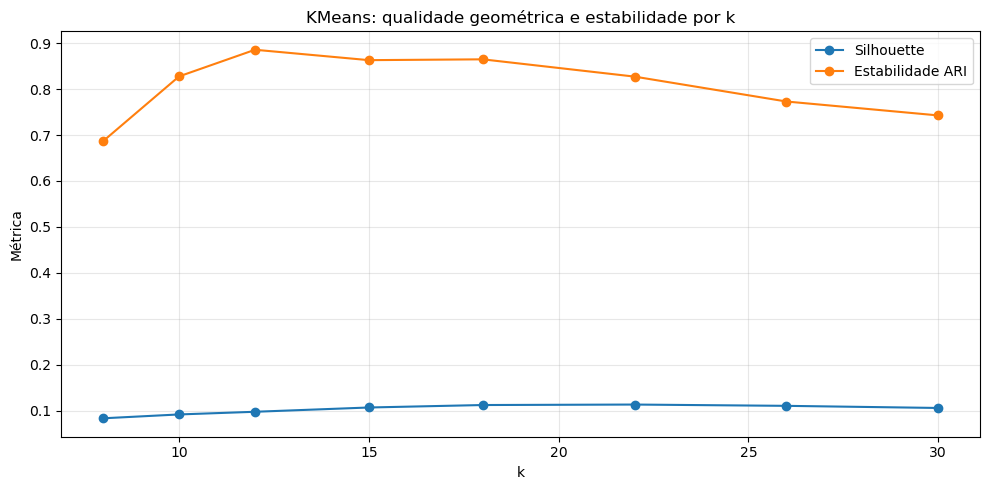

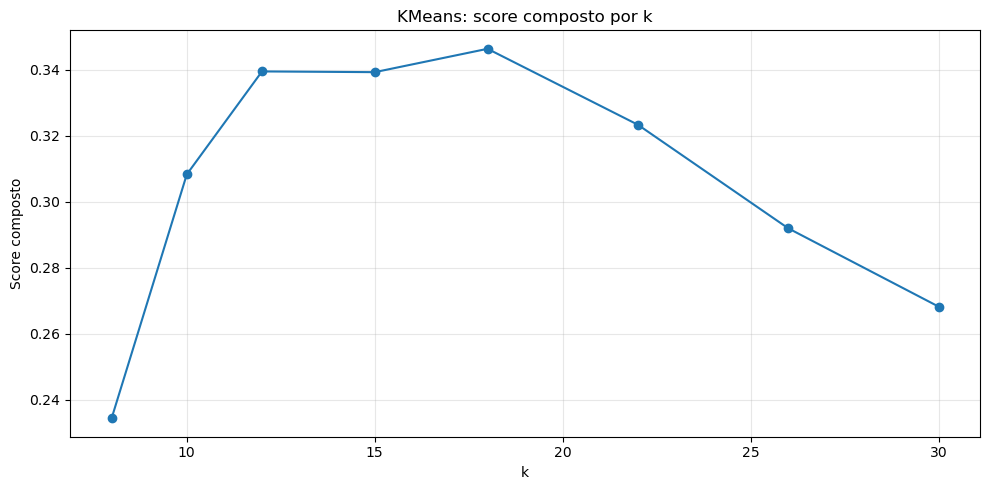

In [16]:
# ============================================================
# 15.1 KMeans: qualidade e estabilidade
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
kmeans_plot = kmeans_grid.sort_values("k")
ax.plot(kmeans_plot["k"], kmeans_plot["silhouette"], marker="o", label="Silhouette")
ax.plot(kmeans_plot["k"], kmeans_plot["stability_ari_mean"], marker="o", label="Estabilidade ARI")
ax.set_title("KMeans: qualidade geométrica e estabilidade por k")
ax.set_xlabel("k")
ax.set_ylabel("Métrica")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "kmeans_qualidade_estabilidade.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(kmeans_plot["k"], kmeans_plot["score"], marker="o")
ax.set_title("KMeans: score composto por k")
ax.set_xlabel("k")
ax.set_ylabel("Score composto")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "kmeans_score_composto.png", dpi=150)
plt.show()

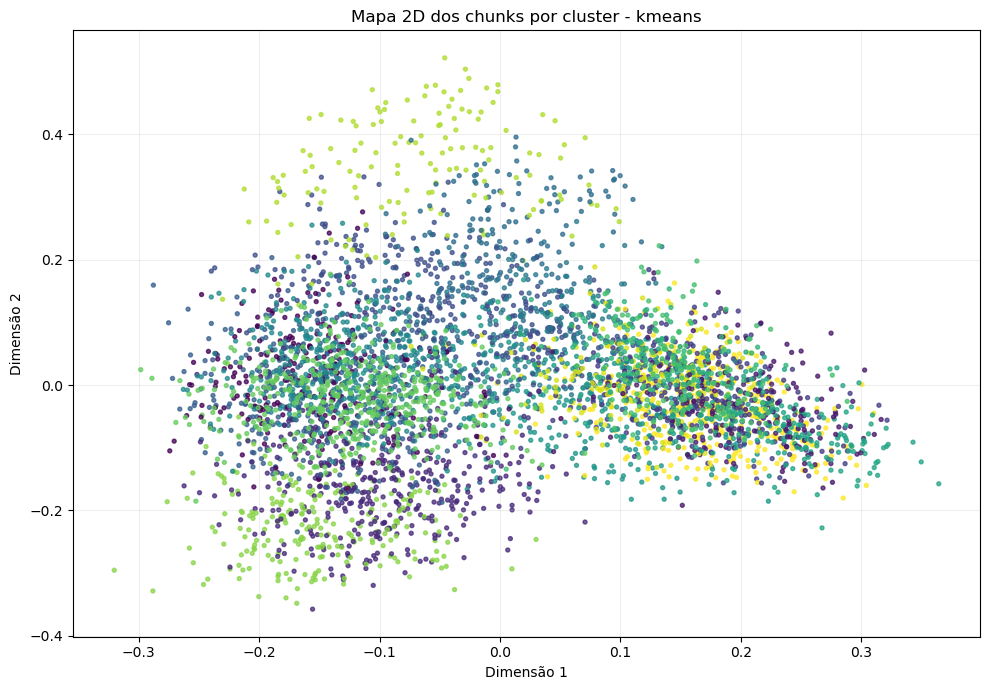

In [17]:
# ============================================================
# 15.2 Mapa 2D dos clusters
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))
labels_for_plot = pd.Categorical(df_model["cluster_label"])
ax.scatter(
    df_model["embedding_x"],
    df_model["embedding_y"],
    c=labels_for_plot.codes,
    s=8,
    alpha=0.75
)
ax.set_title(f"Mapa 2D dos chunks por cluster - {selected_summary.get('method')}")
ax.set_xlabel("Dimensão 1")
ax.set_ylabel("Dimensão 2")
ax.grid(True, alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "clusters_map_2d.png", dpi=150)
plt.show()

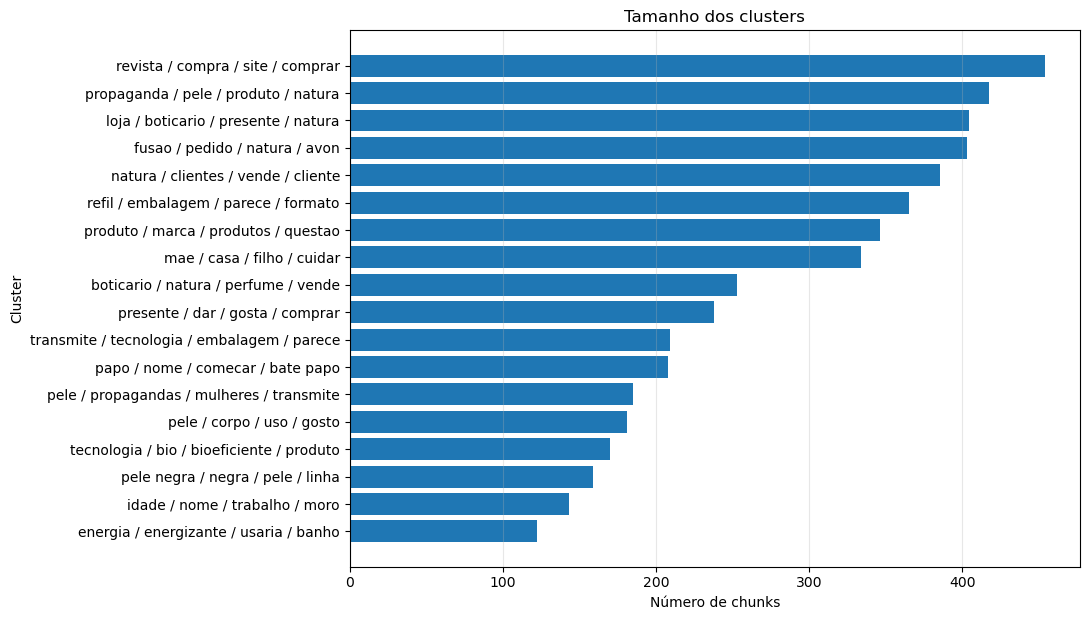

,cluster_label,cluster_auto_label,n_chunks
13,km_013,revista / compra / site / comprar,454
17,km_017,propaganda / pele / produto / natura,417
2,km_002,loja / boticario / presente / natura,404
8,km_008,fusao / pedido / natura / avon,403
5,km_005,natura / clientes / vende / cliente,385
3,km_003,refil / embalagem / parece / formato,365
9,km_009,produto / marca / produtos / questao,346
4,km_004,mae / casa / filho / cuidar,334
14,km_014,boticario / natura / perfume / vende,253
0,km_000,presente / dar / gosta / comprar,238


In [18]:
# ============================================================
# 15.3 Tamanho dos clusters
# ============================================================

cluster_size = (
    df_model.groupby(["cluster_label", "cluster_auto_label"])
    .size()
    .reset_index(name="n_chunks")
    .sort_values("n_chunks", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, max(6, 0.35 * len(cluster_size))))
ax.barh(cluster_size["cluster_auto_label"], cluster_size["n_chunks"])
ax.set_title("Tamanho dos clusters")
ax.set_xlabel("Número de chunks")
ax.set_ylabel("Cluster")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cluster_sizes.png", dpi=150)
plt.show()

display(cluster_size.sort_values("n_chunks", ascending=False))

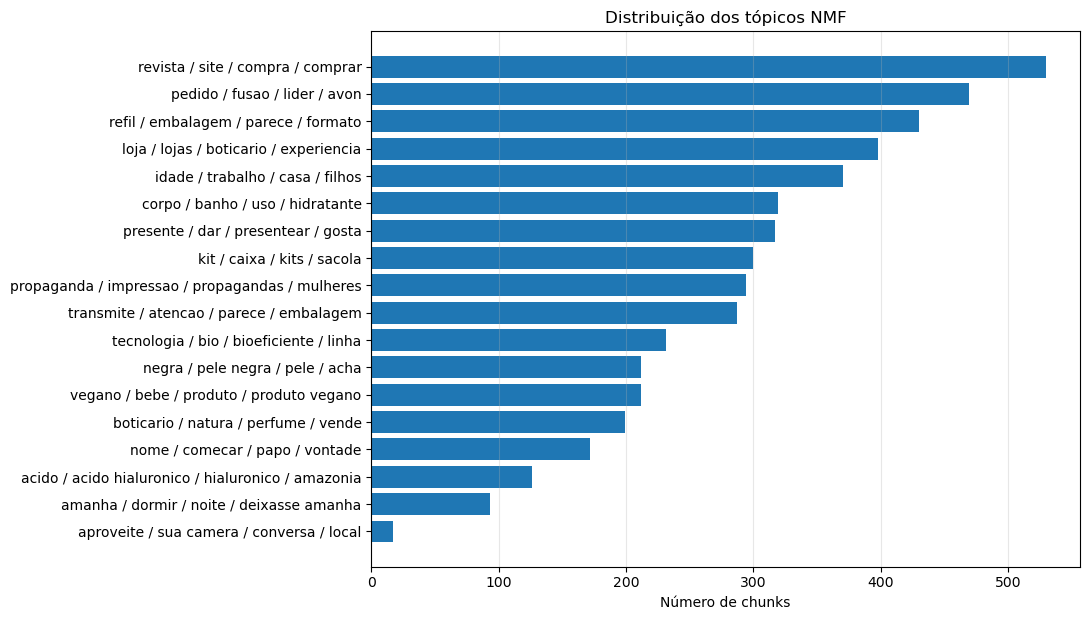

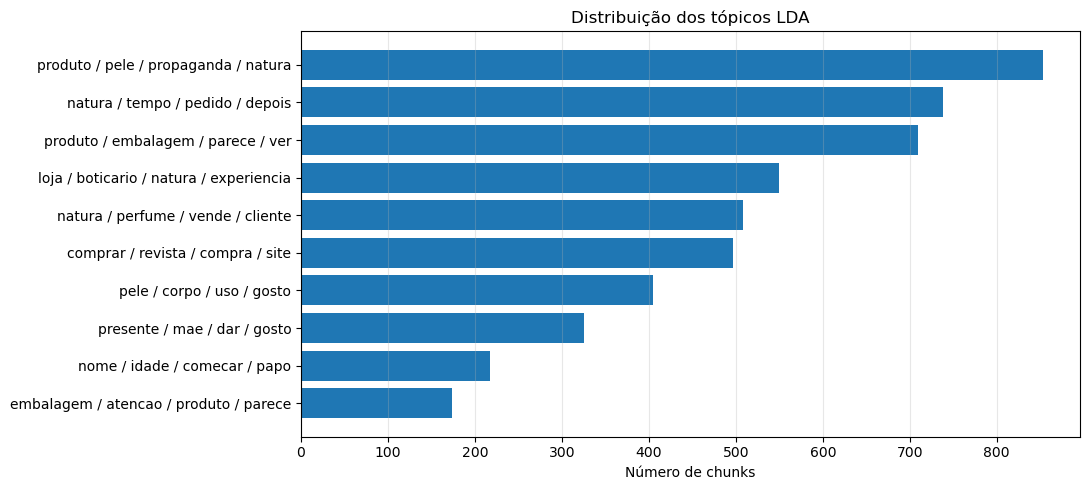

,topic_id,topic_num,top_terms,auto_label_short
0,nmf_00,0,boticario; natura; perfume; vende; marca; marc...,boticario / natura / perfume / vende
1,nmf_01,1,propaganda; impressao; propagandas; mulheres; ...,propaganda / impressao / propagandas / mulheres
2,nmf_02,2,idade; trabalho; casa; filhos; nome; mae; temp...,idade / trabalho / casa / filhos
3,nmf_03,3,corpo; banho; uso; hidratante; passo; creme; p...,corpo / banho / uso / hidratante
4,nmf_04,4,revista; site; compra; comprar; compro; digita...,revista / site / compra / comprar
5,nmf_05,5,presente; dar; presentear; gosta; dar presente...,presente / dar / presentear / gosta
6,nmf_06,6,aproveite; sua camera; conversa; local; camera...,aproveite / sua camera / conversa / local
7,nmf_07,7,refil; embalagem; parece; formato; plastico; d...,refil / embalagem / parece / formato
8,nmf_08,8,transmite; atencao; parece; embalagem; imagem;...,transmite / atencao / parece / embalagem
9,nmf_09,9,negra; pele negra; pele; acha; linha; especifi...,negra / pele negra / pele / acha


,topic_id,topic_num,top_terms,auto_label_short
0,lda_00,0,embalagem; atencao; produto; parece; transmite...,embalagem / atencao / produto / parece
1,lda_01,1,natura; tempo; pedido; depois; avon; casa; lid...,natura / tempo / pedido / depois
2,lda_02,2,loja; boticario; natura; experiencia; perfume;...,loja / boticario / natura / experiencia
3,lda_03,3,produto; embalagem; parece; ver; legal; linha;...,produto / embalagem / parece / ver
4,lda_04,4,natura; perfume; vende; cliente; boticario; ve...,natura / perfume / vende / cliente
5,lda_05,5,pele; corpo; uso; gosto; hidratante; banho; ne...,pele / corpo / uso / gosto
6,lda_06,6,presente; mae; dar; gosto; legal; gosta; passo...,presente / mae / dar / gosto
7,lda_07,7,produto; pele; propaganda; natura; marca; ques...,produto / pele / propaganda / natura
8,lda_08,8,comprar; revista; compra; site; compro; exempl...,comprar / revista / compra / site
9,lda_09,9,nome; idade; comecar; papo; trabalho; vontade;...,nome / idade / comecar / papo


In [19]:
# ============================================================
# 15.4 NMF e LDA: tópicos e distribuição
# ============================================================

nmf_size = df_model["nmf_auto_label"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(nmf_size))))
ax.barh(nmf_size.index, nmf_size.values)
ax.set_title("Distribuição dos tópicos NMF")
ax.set_xlabel("Número de chunks")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "nmf_topic_sizes.png", dpi=150)
plt.show()

lda_size = df_model["lda_auto_label"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(lda_size))))
ax.barh(lda_size.index, lda_size.values)
ax.set_title("Distribuição dos tópicos LDA")
ax.set_xlabel("Número de chunks")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lda_topic_sizes.png", dpi=150)
plt.show()

display(nmf_topics)
display(lda_topics)

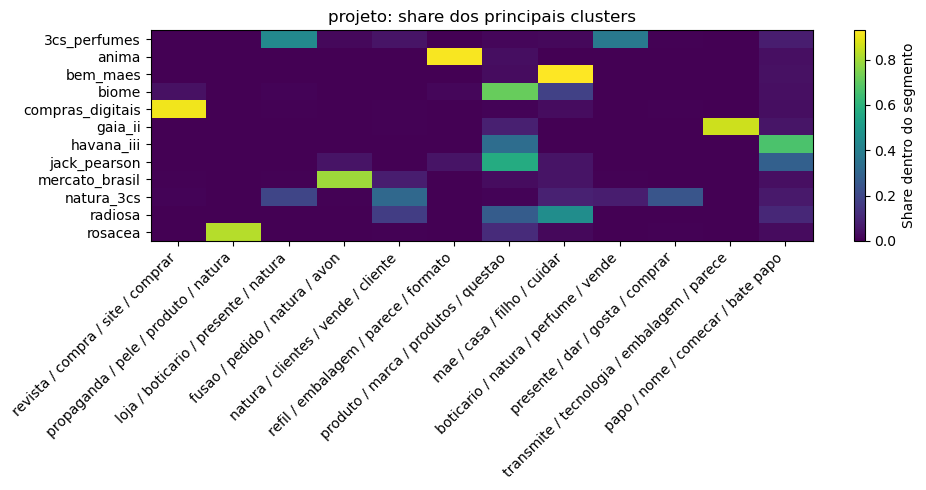

cluster_auto_label,revista / compra / site / comprar,propaganda / pele / produto / natura,loja / boticario / presente / natura,fusao / pedido / natura / avon,natura / clientes / vende / cliente,refil / embalagem / parece / formato,produto / marca / produtos / questao,mae / casa / filho / cuidar,boticario / natura / perfume / vende,presente / dar / gosta / comprar,transmite / tecnologia / embalagem / parece,papo / nome / comecar / bate papo
projeto,,,,,,,,,,,,
3cs_perfumes,0.002,0.000,0.437,0.021,0.050,0.000,0.017,0.021,0.374,0.004,0.000,0.075
anima,0.000,0.000,0.003,0.000,0.000,0.920,0.036,0.003,0.000,0.000,0.000,0.039
bem_maes,0.000,0.000,0.000,0.000,0.000,0.000,0.030,0.929,0.000,0.000,0.000,0.040
biome,0.043,0.000,0.009,0.000,0.000,0.017,0.713,0.178,0.000,0.000,0.000,0.039
compras_digitais,0.908,0.000,0.006,0.000,0.004,0.000,0.011,0.029,0.002,0.004,0.000,0.036
gaia_ii,0.000,0.000,0.000,0.000,0.004,0.000,0.083,0.000,0.000,0.000,0.860,0.054
havana_iii,0.000,0.000,0.000,0.000,0.000,0.000,0.333,0.000,0.000,0.000,0.000,0.667
jack_pearson,0.000,0.000,0.000,0.048,0.000,0.048,0.571,0.048,0.000,0.000,0.000,0.286
mercato_brasil,0.006,0.000,0.004,0.792,0.076,0.000,0.033,0.049,0.004,0.000,0.000,0.037


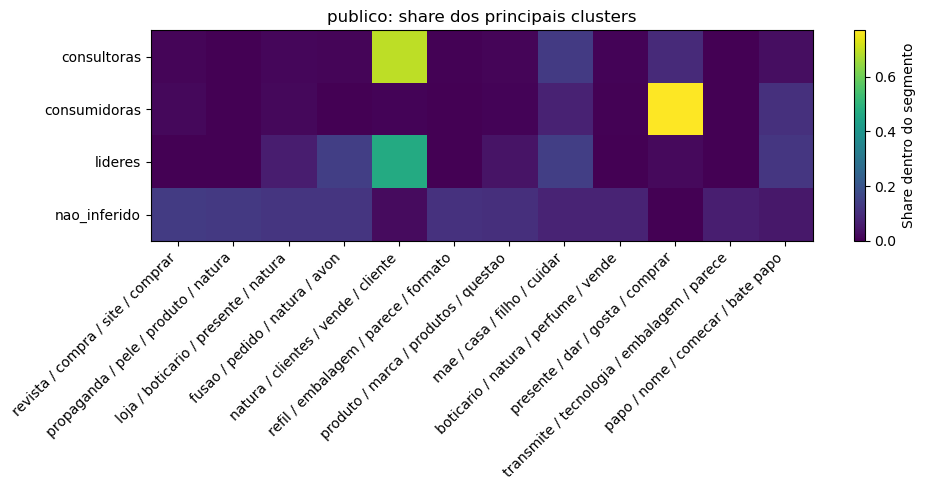

cluster_auto_label,revista / compra / site / comprar,propaganda / pele / produto / natura,loja / boticario / presente / natura,fusao / pedido / natura / avon,natura / clientes / vende / cliente,refil / embalagem / parece / formato,produto / marca / produtos / questao,mae / casa / filho / cuidar,boticario / natura / perfume / vende,presente / dar / gosta / comprar,transmite / tecnologia / embalagem / parece,papo / nome / comecar / bate papo
publico,,,,,,,,,,,,
consultoras,0.010,0.000,0.014,0.010,0.694,0.005,0.010,0.132,0.007,0.091,0.000,0.029
consumidoras,0.016,0.000,0.016,0.000,0.008,0.000,0.008,0.073,0.004,0.769,0.000,0.105
lideres,0.000,0.000,0.061,0.143,0.469,0.000,0.041,0.143,0.000,0.020,0.000,0.122
nao_inferido,0.135,0.126,0.118,0.119,0.021,0.110,0.102,0.077,0.075,0.003,0.063,0.050


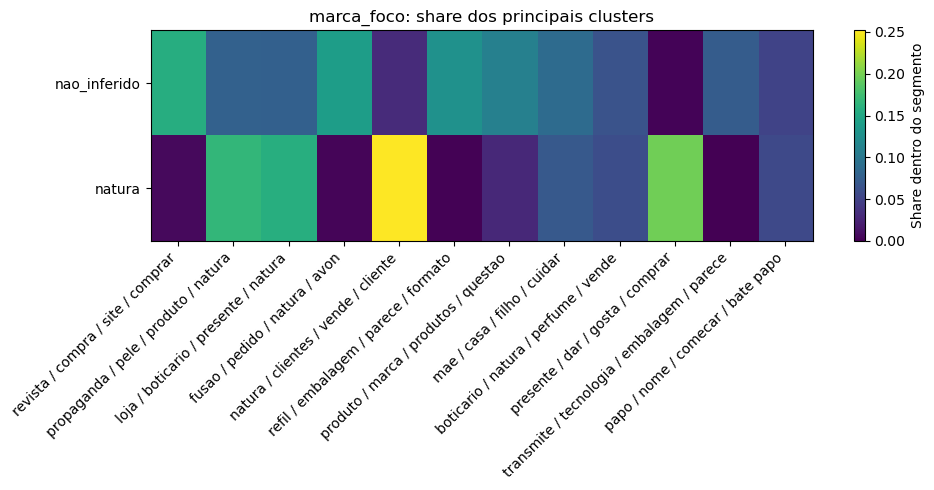

cluster_auto_label,revista / compra / site / comprar,propaganda / pele / produto / natura,loja / boticario / presente / natura,fusao / pedido / natura / avon,natura / clientes / vende / cliente,refil / embalagem / parece / formato,produto / marca / produtos / questao,mae / casa / filho / cuidar,boticario / natura / perfume / vende,presente / dar / gosta / comprar,transmite / tecnologia / embalagem / parece,papo / nome / comecar / bate papo
marca_foco,,,,,,,,,,,,
nao_inferido,0.157,0.078,0.077,0.140,0.031,0.128,0.110,0.088,0.064,0.002,0.074,0.050
natura,0.007,0.167,0.157,0.003,0.252,0.002,0.029,0.071,0.060,0.197,0.000,0.055


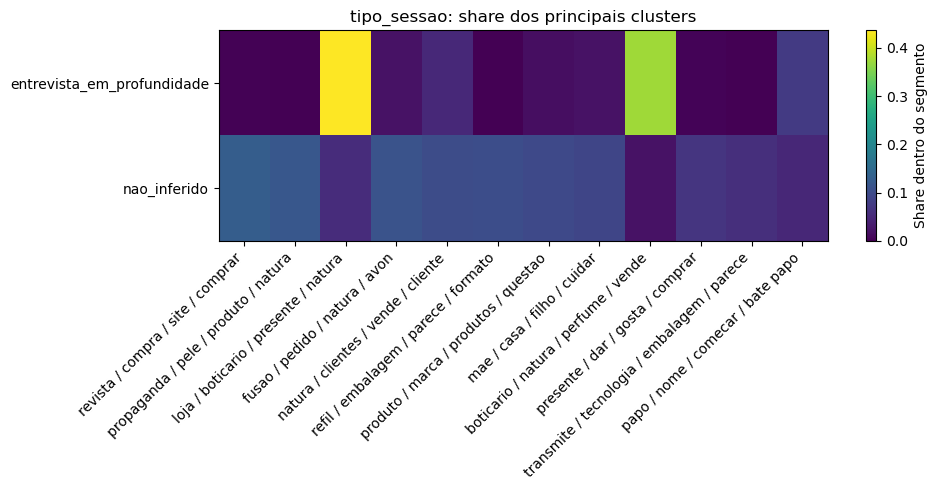

cluster_auto_label,revista / compra / site / comprar,propaganda / pele / produto / natura,loja / boticario / presente / natura,fusao / pedido / natura / avon,natura / clientes / vende / cliente,refil / embalagem / parece / formato,produto / marca / produtos / questao,mae / casa / filho / cuidar,boticario / natura / perfume / vende,presente / dar / gosta / comprar,transmite / tecnologia / embalagem / parece,papo / nome / comecar / bate papo
tipo_sessao,,,,,,,,,,,,
entrevista_em_profundidade,0.002,0.000,0.437,0.021,0.050,0.000,0.017,0.021,0.374,0.004,0.000,0.075
nao_inferido,0.128,0.118,0.055,0.111,0.102,0.103,0.096,0.092,0.021,0.067,0.059,0.049


In [20]:
# ============================================================
# 15.5 Heatmaps de segmentos vs clusters/tópicos
# ============================================================

def plot_share_heatmap(df_in, segment_col, label_col, label_name_col, title, filename, top_n_labels=12, min_seg_n=30):
    seg_counts = df_in[segment_col].value_counts()
    valid_segments = seg_counts[seg_counts >= min_seg_n].index
    sub = df_in[df_in[segment_col].isin(valid_segments)].copy()

    top_labels = sub[label_col].value_counts().head(top_n_labels).index
    sub = sub[sub[label_col].isin(top_labels)]

    if sub.empty:
        print(f"Sem dados suficientes para {segment_col} x {label_col}")
        return

    tab = pd.crosstab(sub[segment_col], sub[label_name_col], normalize="index")
    col_order = sub[label_name_col].value_counts().index.tolist()
    tab = tab[[c for c in col_order if c in tab.columns]]

    fig, ax = plt.subplots(figsize=(max(10, 0.6 * tab.shape[1]), max(5, 0.4 * tab.shape[0])))
    im = ax.imshow(tab.values, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(np.arange(tab.shape[1]))
    ax.set_xticklabels(tab.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(tab.shape[0]))
    ax.set_yticklabels(tab.index)
    fig.colorbar(im, ax=ax, label="Share dentro do segmento")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=150)
    plt.show()
    display(tab.round(3))

for seg in SEGMENT_COLS:
    if df_model[seg].nunique() > 1:
        plot_share_heatmap(
            df_model, seg, "cluster_label", "cluster_auto_label",
            title=f"{seg}: share dos principais clusters",
            filename=f"heatmap_{seg}_clusters.png",
            top_n_labels=12
        )

# 16. Tabelas executivas

As tabelas abaixo são as mais importantes para sair do modelo e entrar em análise real.

In [21]:
# ============================================================
# 16. Tabelas executivas
# ============================================================

display(Markdown("## Modelo de clusterização selecionado"))
display(pd.DataFrame([selected_summary]))

display(Markdown("## KMeans grid search"))
display(kmeans_grid)

if hdbscan_available and len(hdbscan_grid) > 0:
    display(Markdown("## HDBSCAN grid search"))
    display(hdbscan_grid.head(20))

display(Markdown("## Labels automáticos dos clusters"))
display(cluster_labels)

display(Markdown("## Exemplos representativos por cluster"))
display(cluster_examples.head(30))

display(Markdown("## NMF: grid e tópicos"))
display(nmf_grid)
display(nmf_topics)

display(Markdown("## LDA: grid e tópicos"))
display(lda_grid)
display(lda_topics)

display(Markdown("## Top insights por cluster e segmento"))
display(insights_clusters.head(30))

display(Markdown("## Top insights por NMF e segmento"))
display(insights_nmf.head(30))

display(Markdown("## Top insights por LDA e segmento"))
display(insights_lda.head(30))

display(Markdown("## Segmentos mais diferentes da média global"))
display(divergence_clusters.head(30))

## Modelo de clusterização selecionado

,method,k,selection_reason,silhouette,stability_ari_mean,inertia_mean,inertia_std,calinski_harabasz,davies_bouldin,n_clusters,noise_share,largest_cluster_share,score
0,kmeans,18,KMeans escolhido como default por estabilidade...,0.112572,0.864703,984.619041,1.222346,149.295506,2.439287,18,0.0,0.091238,0.346313


## KMeans grid search

,method,k,silhouette,stability_ari_mean,inertia_mean,inertia_std,calinski_harabasz,davies_bouldin,n_clusters,noise_share,largest_cluster_share,score
0,kmeans,18,0.112572,0.864703,984.619041,1.222346,149.295506,2.439287,18,0.0,0.091238,0.346313
1,kmeans,12,0.097893,0.885525,1077.693558,0.270215,171.770925,2.732261,12,0.0,0.121584,0.339458
2,kmeans,15,0.107200,0.862917,1028.071548,0.925138,158.858752,2.566354,15,0.0,0.108722,0.339236
3,kmeans,22,0.113618,0.827110,942.718071,1.464463,135.300579,2.491682,22,0.0,0.083400,0.323298
4,kmeans,10,0.092093,0.827568,1118.092789,0.634408,182.723960,2.863418,10,0.0,0.160169,0.308266
5,kmeans,26,0.110799,0.772932,910.878777,1.273410,125.554728,2.458914,26,0.0,0.077773,0.291911
6,kmeans,30,0.106182,0.742661,884.600426,1.070097,116.021618,2.463987,30,0.0,0.070740,0.268184
7,kmeans,8,0.083710,0.686777,1171.170807,0.291716,192.005070,2.927042,8,0.0,0.260249,0.234363


## Labels automáticos dos clusters

...

,segment_col,segment_value,label_col,label,auto_label,n_chunks_segment_label,n_chunks_segment_total,share_in_segment,global_share,diff_pp_vs_global,lift_vs_global,insight_score,representative_excerpt,insight_sentence
0,projeto,jack_pearson,nmf_topic_id,nmf_11,tecnologia / bio / bioeficiente / linha,182,200,0.910000,0.046423,0.863577,19.602424,2923.762458,Então vamos lá. Essas daqui são algumas das em...,"Em projeto = jack_pearson, o tema 'tecnologia ..."
1,projeto,anima,nmf_topic_id,nmf_07,refil / embalagem / parece / formato,367,406,0.903941,0.086415,0.817526,10.460488,2838.449874,Posso pôr sua bolsa aqui? Me incomoda ficar co...,"Em projeto = anima, o tema 'refil / embalagem ..."
2,projeto,compras_digitais,nmf_topic_id,nmf_04,revista / site / compra / comprar,431,492,0.876016,0.106511,0.769505,8.224636,2396.098522,"eu sou [NOME] o odor muito apurado. Então, eu ...","Em projeto = compras_digitais, o tema 'revista..."
3,projeto,mercato_brasil,nmf_topic_id,nmf_12,pedido / fusao / lider / avon,403,516,0.781008,0.094252,0.686755,8.286342,2016.585619,"Do mesmo tempo, três anos. Eu me cadastrei em ...","Em projeto = mercato_brasil, o tema 'pedido / ..."
4,projeto,gaia_ii,nmf_topic_id,nmf_08,transmite / atencao / parece / embalagem,253,416,0.608173,0.057677,0.550496,10.544492,1329.314345,"Esse do meio tem uma sofisticação? Oi! Isso, i...","Em projeto = gaia_ii, o tema 'transmite / aten..."
5,publico,consumidoras,nmf_topic_id,nmf_05,presente / dar / presentear / gosta,173,261,0.662835,0.063706,0.599129,10.404632,974.784387,"Que legal. Não. E você, já vamos falar mais di...","Em publico = consumidoras, o tema 'presente / ..."
6,projeto,radiosa,nmf_topic_id,nmf_09,negra / pele negra / pele / acha,202,474,0.426160,0.042605,0.383556,10.002707,697.514227,"Ok. Tá ótimo. Meninas, eu queria saber o segui...","Em projeto = radiosa, o tema 'negra / pele neg..."
7,projeto,havana_iii,nmf_topic_id,nmf_03,corpo / banho / uso / hidratante,94,126,0.746032,0.064108,0.681924,11.637160,681.851076,Deixa eu dividir pra vocês a minha tela e quan...,"Em projeto = havana_iii, o tema 'corpo / banho..."
8,projeto,bem_maes,nmf_topic_id,nmf_02,idade / trabalho / casa / filhos,74,101,0.732673,0.074357,0.658316,9.853465,431.300196,"Se eu cair, também espera pouquinho que a gent...","Em projeto = bem_maes, o tema 'idade / trabalh..."
9,projeto,3cs_perfumes,nmf_topic_id,nmf_10,loja / lojas / boticario / experiencia,223,485,0.459794,0.079984,0.379810,5.748578,402.193183,"É, a gente tá tendo alguns problemas, mas tudo...","Em projeto = 3cs_perfumes, o tema 'loja / loja..."


## Top insights por LDA e segmento

,segment_col,segment_value,label_col,label,auto_label,n_chunks_segment_label,n_chunks_segment_total,share_in_segment,global_share,diff_pp_vs_global,lift_vs_global,insight_score,representative_excerpt,insight_sentence
0,projeto,compras_digitais,lda_topic_id,lda_08,comprar / revista / compra / site,423,492,0.859756,0.099879,0.759877,8.607940,2445.403781,"Tá. Então, deixa para a última hora que é test...","Em projeto = compras_digitais, o tema 'comprar..."
1,projeto,rosacea,lda_topic_id,lda_07,produto / pele / propaganda / natura,503,539,0.933210,0.171423,0.761787,5.443905,1702.810158,"Apareceu como mensagem direta, é isso? Fernand...","Em projeto = rosacea, o tema 'produto / pele /..."
2,projeto,anima,lda_topic_id,lda_03,produto / embalagem / parece / ver,368,406,0.906404,0.142484,0.763920,6.361447,1507.223776,Posso pôr sua bolsa aqui? Me incomoda ficar co...,"Em projeto = anima, o tema 'produto / embalage..."
3,publico,consumidoras,lda_topic_id,lda_06,presente / mae / dar / gosto,182,261,0.697318,0.065314,0.632005,10.676475,1113.034801,"Que legal. Não. E você, já vamos falar mais di...","Em publico = consumidoras, o tema 'presente / ..."
4,projeto,mercato_brasil,lda_topic_id,lda_01,natura / tempo / pedido / depois,404,516,0.782946,0.148312,0.634634,5.279049,1097.114174,"Você começou a vender na pandemia, praticament...","Em projeto = mercato_brasil, o tema 'natura / ..."
5,projeto,radiosa,lda_topic_id,lda_05,pele / corpo / uso / gosto,267,474,0.563291,0.081391,0.481900,6.920831,761.818121,"Mas tenho insistido nisso para aprender, falo,...","Em projeto = radiosa, o tema 'pele / corpo / u..."
6,projeto,jack_pearson,lda_topic_id,lda_03,produto / embalagem / parece / ver,179,200,0.895000,0.142484,0.752516,6.281410,711.407981,"Então, tudo que ela vai oferecer, E no futuro ...","Em projeto = jack_pearson, o tema 'produto / e..."
7,projeto,3cs_perfumes,lda_topic_id,lda_02,loja / boticario / natura / experiencia,295,485,0.608247,0.110531,0.497717,5.502980,661.156743,"Eu começo, Dri? Posso começar? Pode começar, W...","Em projeto = 3cs_perfumes, o tema 'loja / boti..."
8,tipo_sessao,entrevista_em_profundidade,lda_topic_id,lda_02,loja / boticario / natura / experiencia,295,485,0.608247,0.110531,0.497717,5.502980,661.156743,"Eu começo, Dri? Posso começar? Pode começar, W...","Em tipo_sessao = entrevista_em_profundidade, o..."
9,projeto,havana_iii,lda_topic_id,lda_05,pele / corpo / uso / gosto,95,126,0.753968,0.081391,0.672578,9.263570,527.999759,Deixa eu dividir pra vocês a minha tela e quan...,"Em projeto = havana_iii, o tema 'pele / corpo ..."


## Segmentos mais diferentes da média global

,segment_col,segment_value,n_chunks,label_col,js_divergence_vs_global
0,projeto,havana_iii,126,cluster_label,0.860316
1,projeto,jack_pearson,200,cluster_label,0.720104
2,projeto,bem_maes,101,cluster_label,0.715528
3,projeto,anima,406,cluster_label,0.676328
4,projeto,gaia_ii,416,cluster_label,0.658360
5,publico,consumidoras,261,cluster_label,0.593335
6,projeto,compras_digitais,492,cluster_label,0.591654
7,projeto,rosacea,539,cluster_label,0.555014
8,projeto,biome,236,cluster_label,0.542996
9,projeto,radiosa,474,cluster_label,0.536996


# 17. Resumo automático das análises

Esta seção produz um relatório em Markdown e salva o arquivo em `relatorio_clusterizacao_topicos.md`.

In [22]:
# ============================================================
# 17. Relatório automático
# ============================================================

def fmt_pct(x):
    try:
        return f"{x:.1%}"
    except Exception:
        return "n/a"

def top_table_md(df_in, cols, n=10):
    if df_in is None or len(df_in) == 0:
        return "_Sem dados._"
    existing = [c for c in cols if c in df_in.columns]
    return df_in[existing].head(n).to_markdown(index=False)

n_chunks = len(df_model)
n_docs = df_model["doc_id"].nunique()
n_clusters = df_model["cluster_label"].nunique()
largest_share = df_model["cluster_label"].value_counts(normalize=True).max()
selected_method = selected_summary.get("method", "n/a")

top_cluster_sizes = (
    df_model.groupby(["cluster_label", "cluster_auto_label"])
    .size()
    .reset_index(name="n_chunks")
    .assign(share=lambda x: x["n_chunks"] / n_chunks)
    .sort_values("n_chunks", ascending=False)
)

model_comparison_rows = []
model_comparison_rows.append({
    "modelo": "KMeans selecionado",
    "parametro": f"k={best_k}",
    "criterio": f"silhouette={kmeans_grid.iloc[0]['silhouette']:.3f}; estabilidade={kmeans_grid.iloc[0]['stability_ari_mean']:.3f}; score={kmeans_grid.iloc[0]['score']:.3f}",
})
if hdbscan_available and len(hdbscan_grid) > 0:
    model_comparison_rows.append({
        "modelo": "Melhor HDBSCAN",
        "parametro": f"min_cluster_size={hdbscan_grid.iloc[0]['min_cluster_size']}; min_samples={hdbscan_grid.iloc[0]['min_samples']}",
        "criterio": f"silhouette_non_noise={hdbscan_grid.iloc[0]['silhouette_non_noise']:.3f}; ruido={hdbscan_grid.iloc[0]['noise_share']:.1%}; score={hdbscan_grid.iloc[0]['score']:.3f}",
    })
model_comparison_rows.append({
    "modelo": "Melhor NMF",
    "parametro": f"n_topics={best_nmf_topics}",
    "criterio": f"diversidade={nmf_grid.iloc[0]['topic_diversity']:.3f}; dominancia={nmf_grid.iloc[0]['mean_dominant_topic_weight']:.3f}; score={nmf_grid.iloc[0]['score']:.3f}",
})
model_comparison_rows.append({
    "modelo": "Melhor LDA",
    "parametro": f"n_topics={best_lda_topics}",
    "criterio": f"diversidade={lda_grid.iloc[0]['topic_diversity']:.3f}; dominancia={lda_grid.iloc[0]['mean_dominant_topic_weight']:.3f}; score={lda_grid.iloc[0]['score']:.3f}",
})
model_comparison = pd.DataFrame(model_comparison_rows)

report = f'''
# Relatório de clusterização, tópicos e insights

Run ID: `{RUN_ID}`

## 1. Base analisada

- Chunks: **{n_chunks:,}**
- Entrevistas/documentos: **{n_docs:,}**
- Texto usado para embeddings: `text_for_embedding`
- Texto usado para rótulos/tópicos: `text_for_keywords`

## 2. Modelo de clusterização selecionado

- Método selecionado: **{selected_method}**
- Número de clusters: **{n_clusters}**
- Maior cluster: **{fmt_pct(largest_share)}** da base
- Razão da seleção: {selected_summary.get("selection_reason", "Critério composto de qualidade, estabilidade e interpretabilidade.")}

### Comparação de modelos

{model_comparison.to_markdown(index=False)}

## 3. Interpretação dos clusters

Os clusters devem ser lidos como agrupamentos semânticos. O rótulo automático é uma aproximação gerada por TF-IDF; ele precisa ser validado com os exemplos representativos.

### Maiores clusters

{top_table_md(top_cluster_sizes, ["cluster_label", "cluster_auto_label", "n_chunks", "share"], n=15)}

### Labels automáticos

{top_table_md(cluster_labels, ["cluster_label", "n_chunks", "auto_label_short", "top_terms"], n=20)}

## 4. NMF

NMF é usado como leitura auxiliar de tópicos por vocabulário. Ele tende a ser mais interpretável que LDA quando usamos TF-IDF.

- Melhor número de tópicos: **{best_nmf_topics}**

{top_table_md(nmf_topics, ["topic_id", "auto_label_short", "top_terms"], n=20)}

## 5. LDA

LDA é usado como comparação probabilística. Se os tópicos aparecerem genéricos demais, priorize NMF e clusters semânticos.

- Melhor número de tópicos: **{best_lda_topics}**

{top_table_md(lda_topics, ["topic_id", "auto_label_short", "top_terms"], n=20)}

## 6. Principais insights por segmento

A tabela abaixo prioriza combinações segmento-tema com maior lift e tamanho mínimo.

### Clusters por segmento

{top_table_md(insights_clusters, ["segment_col", "segment_value", "auto_label", "n_chunks_segment_label", "share_in_segment", "global_share", "lift_vs_global", "insight_sentence"], n=20)}

### NMF por segmento

{top_table_md(insights_nmf, ["segment_col", "segment_value", "auto_label", "n_chunks_segment_label", "share_in_segment", "global_share", "lift_vs_global", "insight_sentence"], n=15)}

### LDA por segmento

{top_table_md(insights_lda, ["segment_col", "segment_value", "auto_label", "n_chunks_segment_label", "share_in_segment", "global_share", "lift_vs_global", "insight_sentence"], n=15)}

## 7. Segmentos que mais diferem da média

{top_table_md(divergence_clusters, ["segment_col", "segment_value", "n_chunks", "js_divergence_vs_global"], n=20)}

## 8. Como transformar isso em insights reais

1. Validar manualmente os 5 exemplos representativos de cada cluster.
2. Renomear clusters com linguagem de negócio, não com palavras soltas.
3. Fundir clusters muito parecidos e dividir clusters com exemplos heterogêneos.
4. Priorizar insights com lift alto, share relevante e pelo menos 8 chunks no segmento.
5. Sempre incluir uma evidência textual curta para cada insight.
6. Separar resultado descritivo de recomendação: o modelo mostra padrão; a recomendação vem da interpretação do analista.
'''

report_path = RUN_DIR / "relatorio_clusterizacao_topicos.md"
report_path.write_text(report, encoding="utf-8")

display(Markdown(report))
print("Relatório salvo em:", report_path)


# Relatório de clusterização, tópicos e insights

Run ID: `20260520_113457`

## 1. Base analisada

- Chunks: **4,976**
- Entrevistas/documentos: **131**
- Texto usado para embeddings: `text_for_embedding`
- Texto usado para rótulos/tópicos: `text_for_keywords`

## 2. Modelo de clusterização selecionado

- Método selecionado: **kmeans**
- Número de clusters: **18**
- Maior cluster: **9.1%** da base
- Razão da seleção: KMeans escolhido como default por estabilidade, cobertura total e interpretabilidade.

### Comparação de modelos

| modelo             | parametro   | criterio                                          |
|:-------------------|:------------|:--------------------------------------------------|
| KMeans selecionado | k=18        | silhouette=0.113; estabilidade=0.865; score=0.346 |
| Melhor NMF         | n_topics=18 | diversidade=0.833; dominancia=0.512; score=0.763  |
| Melhor LDA         | n_topics=10 | diversidade=0.760; dominancia=0.648; score=0.778  |

## 3. Interpretação dos clusters

Os clusters devem ser lidos como agrupamentos semânticos. O rótulo automático é uma aproximação gerada por TF-IDF; ele precisa ser validado com os exemplos representativos.

### Maiores clusters

| cluster_label   | cluster_auto_label                          |   n_chunks |     share |
|:----------------|:--------------------------------------------|-----------:|----------:|
| km_013          | revista / compra / site / comprar           |        454 | 0.0912379 |
| km_017          | propaganda / pele / produto / natura        |        417 | 0.0838023 |
| km_002          | loja / boticario / presente / natura        |        404 | 0.0811897 |
| km_008          | fusao / pedido / natura / avon              |        403 | 0.0809887 |
| km_005          | natura / clientes / vende / cliente         |        385 | 0.0773714 |
| km_003          | refil / embalagem / parece / formato        |        365 | 0.0733521 |
| km_009          | produto / marca / produtos / questao        |        346 | 0.0695338 |
| km_004          | mae / casa / filho / cuidar                 |        334 | 0.0671222 |
| km_014          | boticario / natura / perfume / vende        |        253 | 0.0508441 |
| km_000          | presente / dar / gosta / comprar            |        238 | 0.0478296 |
| km_010          | transmite / tecnologia / embalagem / parece |        209 | 0.0420016 |
| km_006          | papo / nome / comecar / bate papo           |        208 | 0.0418006 |
| km_001          | pele / propagandas / mulheres / transmite   |        185 | 0.0371785 |
| km_007          | pele / corpo / uso / gosto                  |        181 | 0.0363746 |
| km_012          | tecnologia / bio / bioeficiente / produto   |        170 | 0.034164  |

### Labels automáticos

| cluster_label   |   n_chunks | auto_label_short                            | top_terms                                                                                                                                                                                                      |
|:----------------|-----------:|:--------------------------------------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| km_013          |        454 | revista / compra / site / comprar           | revista; compra; site; comprar; compro; exemplo; consultora; espaco; digital; manda; pelo; loja; interativa; aplicativo; produtos; produto; revista interativa; promocao; espaco digital; acha                 |
| km_017          |        417 | propaganda / pele / produto / natura        | propaganda; pele; produto; natura; acido; amazonia; achei; questao; dessa; impressao; natural; cuidado; tempo; pode; hialuronico; acido hialuronico; natureza; traz; mostra; palavras                          |
| km_002          |        404 | loja / boticario / presente / natura        | loja; boticario; presente; natura; perfumaria; experiencia; lojas; perfume; ponto; consumidor; shopping; dentro; atencao; cara; marca; caixa; embalagem; presentes; pode; atendimento                          |
| km_008          |        403 | fusao / pedido / natura / avon              | fusao; pedido; natura; avon; lider; avo; vender; teve; ciclo; pontos; gerente; mudou; aplicativo; grupo; negocio; duas; exemplo; chegar; cliente; depois                                                       |
| km_005          |        385 | natura / clientes / vende / cliente         | natura; clientes; vende; cliente; boticario; kit; perfume; presente; kits; vender; vem; entendi; marcas; exemplo; vendo; sempre; bastante; sabonete; comprar; hidratante                                       |
| km_003          |        365 | refil / embalagem / parece / formato        | refil; embalagem; parece; formato; plastico; ecos; legal; cor; diferente; atual; design; material; ver; acham; visual; lembra; produto; natureza; ficar; bonito                                                |
| km_009          |        346 | produto / marca / produtos / questao        | produto; marca; produtos; questao; shampoo; natura; cabelo; barra; natureza; embalagem; uso; natural; propaganda; sempre; sabonete; marcas; biome; condicionador; ambiente; pode                               |
| km_004          |        334 | mae / casa / filho / cuidar                 | mae; casa; filho; cuidar; filhos; sempre; tempo; vida; momento; cabelo; trabalho; semana; seu; gosto; mulher; depois; sua; nome; maes; questao                                                                 |
| km_014          |        253 | boticario / natura / perfume / vende        | boticario; natura; perfume; vende; perfumaria; consultora; vender; perfumes; presente; venda; amostra; relacao; ponto; compra; embalagem; loja; falava; trouxe; marca; fragrancia                              |
| km_000          |        238 | presente / dar / gosta / comprar            | presente; dar; gosta; comprar; aniversario; presentear; mae; gosto; dar presente; legal; sempre; loja; exemplo; perfume; sua; costuma; presentes; entendi; dou; dei                                            |
| km_010          |        209 | transmite / tecnologia / embalagem / parece | transmite; tecnologia; embalagem; parece; inovacao; produto; atencao; imagem; avancada; tecnologia avancada; ideia; chama atencao; chama; mostra; passo; sofisticacao; cor; pele; passo passo; transmite ideia |
| km_006          |        208 | papo / nome / comecar / bate papo           | papo; nome; comecar; bate papo; bate; conversa; vontade; ouvir; pode; ideia; conversar; prazer; microfone; entrar; ver; pouquinho; mundo; ficar; camera; depois                                                |
| km_001          |        185 | pele / propagandas / mulheres / transmite   | pele; propagandas; mulheres; transmite; impressao; produto; imagens; transmitem; passa; mulher; idade; olhando; propaganda; olhar; parece; conta; rosto; mensagem; diversidade; foto                           |
| km_007          |        181 | pele / corpo / uso / gosto                  | pele; corpo; uso; gosto; hidratante; oleo; banho; creme; passo; cheiro; fica; passar; pele corpo; usa; rosto; hidratacao; depois; quero; faco; partes                                                          |
| km_012          |        170 | tecnologia / bio / bioeficiente / produto   | tecnologia; bio; bioeficiente; produto; nome; palavra; linha; eficiente; bioinovacao; cabeca; produtos; homem; dermotech; pele; biotec; otimo; bioexpert; barba; natural; nomes                                |
| km_016          |        159 | pele negra / negra / pele / linha           | pele negra; negra; pele; linha; hidratacao; marca; acha; produto; seria; hidratante; oleo; especifico; saber; produtos; acham; quero saber; negras; natura; quero; ver                                         |
| km_015          |        143 | idade / nome / trabalho / moro              | idade; nome; trabalho; moro; nome idade; filhos; mora; paulo; comecar; casada; pouquinho; prazer; vida; legal; tempo; area; natura; tarde; conhecer; otimo                                                     |
| km_011          |        122 | energia / energizante / usaria / banho      | energia; energizante; usaria; banho; corpo; compraria; gel; linha; pele; isabela; produto; usar; disposicao; escova; noite; sabonete; manha; thais; circulacao; entendi                                        |

## 4. NMF

NMF é usado como leitura auxiliar de tópicos por vocabulário. Ele tende a ser mais interpretável que LDA quando usamos TF-IDF.

- Melhor número de tópicos: **18**

| topic_id   | auto_label_short                                   | top_terms                                                                                                                                                                  |
|:-----------|:---------------------------------------------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| nmf_00     | boticario / natura / perfume / vende               | boticario; natura; perfume; vende; marca; marcas; vender; perfumaria; perfumes; avon; essencial; clientes; cliente; natura boticario; cheiro                               |
| nmf_01     | propaganda / impressao / propagandas / mulheres    | propaganda; impressao; propagandas; mulheres; mulher; produto; marca; tempo; expressao; pele; amiga tempo; passa; duas semanas; mostra; idade                              |
| nmf_02     | idade / trabalho / casa / filhos                   | idade; trabalho; casa; filhos; nome; mae; tempo; vida; filho; semana; mora; moro; seu; momento; faco                                                                       |
| nmf_03     | corpo / banho / uso / hidratante                   | corpo; banho; uso; hidratante; passo; creme; pele; sabonete; gosto; oleo; cheiro; rosto; usa; usar; noite                                                                  |
| nmf_04     | revista / site / compra / comprar                  | revista; site; compra; comprar; compro; digital; espaco; interativa; consultora; revista interativa; manda; espaco digital; pelo; exemplo; aplicativo                      |
| nmf_05     | presente / dar / presentear / gosta                | presente; dar; presentear; gosta; dar presente; aniversario; mae; comprar; presentes; natal; gosto; maes; legal; sempre; comprar presente                                  |
| nmf_06     | aproveite / sua camera / conversa / local          | aproveite; sua camera; conversa; local; camera; conexao; bate papo; estiver; estamos; bate; papo; sua; diferentes; tenha; seu                                              |
| nmf_07     | refil / embalagem / parece / formato               | refil; embalagem; parece; formato; plastico; diferente; ecos; legal; cor; design; material; visual; atual; acham; lembra                                                   |
| nmf_08     | transmite / atencao / parece / embalagem           | transmite; atencao; parece; embalagem; imagem; tecnologia; chama atencao; chama; inovacao; produto; sofisticacao; avancada; tecnologia avancada; chamou; ideia             |
| nmf_09     | negra / pele negra / pele / acha                   | negra; pele negra; pele; acha; linha; especifico; saber; hidratacao; marca; seria; quero saber; branca; negras; peles; produto                                             |
| nmf_10     | loja / lojas / boticario / experiencia             | loja; lojas; boticario; experiencia; shopping; perfumaria; natura; consumidor; ponto; loja natura; atendimento; atencao; varejo; dentro; vitrine                           |
| nmf_11     | tecnologia / bio / bioeficiente / linha            | tecnologia; bio; bioeficiente; linha; produtos; nome; produto; cabeca; palavra; homem; eficiente; bioinovacao; dermotech; natural; seria                                   |
| nmf_12     | pedido / fusao / lider / avon                      | pedido; fusao; lider; avon; natura; avo; teve; pontos; ciclo; vender; mudou; minimo; gerente; grupo; aconteceu                                                             |
| nmf_13     | nome / comecar / papo / vontade                    | nome; comecar; papo; vontade; bate papo; bate; ouvir; prazer; microfone; conversar; importante; papo comecar; fiquem; prontinho; acionar microfone                         |
| nmf_14     | acido / acido hialuronico / hialuronico / amazonia | acido; acido hialuronico; hialuronico; amazonia; propaganda; tucuma; producao; pele amazonia; producao acido; hidratacao; pele; corpo; natureza; sentisse; sentisse pele   |
| nmf_15     | vegano / bebe / produto / produto vegano           | vegano; bebe; produto; produto vegano; questao; frescor; natural; mar; ambiente; massagem; base; mergulho; cuidado; barra; sensacao                                        |
| nmf_16     | amanha / dormir / noite / deixasse amanha          | amanha; dormir; noite; deixasse amanha; deixasse; cuida; dormir melhor; enquanto cuida; cuida pele; melhor enquanto; enquanto; ritual; cuidar; natura noite; ritual dormir |
| nmf_17     | kit / caixa / kits / sacola                        | kit; caixa; kits; sacola; presente; vem; embalagem; cliente; sabonete; presentes; caixas; entrega; montar; preco; dentro                                                   |

## 5. LDA

LDA é usado como comparação probabilística. Se os tópicos aparecerem genéricos demais, priorize NMF e clusters semânticos.

- Melhor número de tópicos: **10**

| topic_id   | auto_label_short                        | top_terms                                                                                                                                            |
|:-----------|:----------------------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------|
| lda_00     | embalagem / atencao / produto / parece  | embalagem; atencao; produto; parece; transmite; chama; sofisticacao; chama atencao; cor; imagem; chamou; tecnologia; inovacao; chamou atencao; ideia |
| lda_01     | natura / tempo / pedido / depois        | natura; tempo; pedido; depois; avon; casa; lider; sempre; fusao; seu; pode; teve; trabalho; duas; avo                                                |
| lda_02     | loja / boticario / natura / experiencia | loja; boticario; natura; experiencia; perfume; perfumaria; lojas; marca; questao; ponto; produtos; shopping; comprar; presente; consumidor           |
| lda_03     | produto / embalagem / parece / ver      | produto; embalagem; parece; ver; legal; linha; refil; produtos; diferente; natural; shampoo; pode; natureza; formato; nome                           |
| lda_04     | natura / perfume / vende / cliente      | natura; perfume; vende; cliente; boticario; vem; linha; marca; kit; vender; clientes; marcas; sabonete; avon; produtos                               |
| lda_05     | pele / corpo / uso / gosto              | pele; corpo; uso; gosto; hidratante; banho; negra; creme; oleo; pele negra; cheiro; fica; usar; sabonete; cabelo                                     |
| lda_06     | presente / mae / dar / gosto            | presente; mae; dar; gosto; legal; gosta; passo; maes; sua; sempre; comprar; presentear; aniversario; casa; natal                                     |
| lda_07     | produto / pele / propaganda / natura    | produto; pele; propaganda; natura; marca; questao; produtos; pode; cuidado; impressao; dessa; achei; tempo; mostra; mulher                           |
| lda_08     | comprar / revista / compra / site       | comprar; revista; compra; site; compro; exemplo; produto; pelo; consultora; produtos; sempre; promocao; manda; digital; aplicativo                   |
| lda_09     | nome / idade / comecar / papo           | nome; idade; comecar; papo; trabalho; vontade; pouquinho; pode; sua; conversa; prazer; ouvir; bate; bate papo; moro                                  |

## 6. Principais insights por segmento

A tabela abaixo prioriza combinações segmento-tema com maior lift e tamanho mínimo.

### Clusters por segmento

| segment_col   | segment_value              | auto_label                                  |   n_chunks_segment_label |   share_in_segment |   global_share |   lift_vs_global | insight_sentence                                                                                                                                              |
|:--------------|:---------------------------|:--------------------------------------------|-------------------------:|-------------------:|---------------:|-----------------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------|
| projeto       | havana_iii                 | energia / energizante / usaria / banho      |                      122 |           0.968254 |      0.0245177 |         39.4921  | Em projeto = havana_iii, o tema 'energia / energizante / usaria / banho' aparece em 96.8% dos chunks vs. 2.5% no total (lift 39.49x; n=122).                  |
| projeto       | jack_pearson               | tecnologia / bio / bioeficiente / produto   |                      170 |           0.85     |      0.034164  |         24.88    | Em projeto = jack_pearson, o tema 'tecnologia / bio / bioeficiente / produto' aparece em 85.0% dos chunks vs. 3.4% no total (lift 24.88x; n=170).             |
| projeto       | anima                      | refil / embalagem / parece / formato        |                      358 |           0.881773 |      0.0733521 |         12.0211  | Em projeto = anima, o tema 'refil / embalagem / parece / formato' aparece em 88.2% dos chunks vs. 7.3% no total (lift 12.02x; n=358).                         |
| projeto       | compras_digitais           | revista / compra / site / comprar           |                      432 |           0.878049 |      0.0912379 |          9.62372 | Em projeto = compras_digitais, o tema 'revista / compra / site / comprar' aparece em 87.8% dos chunks vs. 9.1% no total (lift 9.62x; n=432).                  |
| projeto       | rosacea                    | propaganda / pele / produto / natura        |                      417 |           0.773655 |      0.0838023 |          9.23191 | Em projeto = rosacea, o tema 'propaganda / pele / produto / natura' aparece em 77.4% dos chunks vs. 8.4% no total (lift 9.23x; n=417).                        |
| projeto       | mercato_brasil             | fusao / pedido / natura / avon              |                      388 |           0.751938 |      0.0809887 |          9.28447 | Em projeto = mercato_brasil, o tema 'fusao / pedido / natura / avon' aparece em 75.2% dos chunks vs. 8.1% no total (lift 9.28x; n=388).                       |
| publico       | consumidoras               | presente / dar / gosta / comprar            |                      190 |           0.727969 |      0.0478296 |         15.2201  | Em publico = consumidoras, o tema 'presente / dar / gosta / comprar' aparece em 72.8% dos chunks vs. 4.8% no total (lift 15.22x; n=190).                      |
| publico       | consultoras                | natura / clientes / vende / cliente         |                      290 |           0.651685 |      0.0773714 |          8.42282 | Em publico = consultoras, o tema 'natura / clientes / vende / cliente' aparece em 65.2% dos chunks vs. 7.7% no total (lift 8.42x; n=290).                     |
| projeto       | gaia_ii                    | transmite / tecnologia / embalagem / parece |                      208 |           0.5      |      0.0420016 |         11.9043  | Em projeto = gaia_ii, o tema 'transmite / tecnologia / embalagem / parece' aparece em 50.0% dos chunks vs. 4.2% no total (lift 11.90x; n=208).                |
| projeto       | bem_maes                   | mae / casa / filho / cuidar                 |                       92 |           0.910891 |      0.0671222 |         13.5706  | Em projeto = bem_maes, o tema 'mae / casa / filho / cuidar' aparece em 91.1% dos chunks vs. 6.7% no total (lift 13.57x; n=92).                                |
| projeto       | biome                      | produto / marca / produtos / questao        |                      164 |           0.694915 |      0.0695338 |          9.99393 | Em projeto = biome, o tema 'produto / marca / produtos / questao' aparece em 69.5% dos chunks vs. 7.0% no total (lift 9.99x; n=164).                          |
| projeto       | gaia_ii                    | pele / propagandas / mulheres / transmite   |                      161 |           0.387019 |      0.0371785 |         10.4098  | Em projeto = gaia_ii, o tema 'pele / propagandas / mulheres / transmite' aparece em 38.7% dos chunks vs. 3.7% no total (lift 10.41x; n=161).                  |
| projeto       | radiosa                    | pele negra / negra / pele / linha           |                      157 |           0.331224 |      0.0319534 |         10.3658  | Em projeto = radiosa, o tema 'pele negra / negra / pele / linha' aparece em 33.1% dos chunks vs. 3.2% no total (lift 10.37x; n=157).                          |
| projeto       | radiosa                    | pele / corpo / uso / gosto                  |                      163 |           0.343882 |      0.0363746 |          9.4539  | Em projeto = radiosa, o tema 'pele / corpo / uso / gosto' aparece em 34.4% dos chunks vs. 3.6% no total (lift 9.45x; n=163).                                  |
| projeto       | 3cs_perfumes               | boticario / natura / perfume / vende        |                      180 |           0.371134 |      0.0508441 |          7.29946 | Em projeto = 3cs_perfumes, o tema 'boticario / natura / perfume / vende' aparece em 37.1% dos chunks vs. 5.1% no total (lift 7.30x; n=180).                   |
| tipo_sessao   | entrevista_em_profundidade | boticario / natura / perfume / vende        |                      180 |           0.371134 |      0.0508441 |          7.29946 | Em tipo_sessao = entrevista_em_profundidade, o tema 'boticario / natura / perfume / vende' aparece em 37.1% dos chunks vs. 5.1% no total (lift 7.30x; n=180). |
| projeto       | 3cs_perfumes               | loja / boticario / presente / natura        |                      210 |           0.43299  |      0.0811897 |          5.33306 | Em projeto = 3cs_perfumes, o tema 'loja / boticario / presente / natura' aparece em 43.3% dos chunks vs. 8.1% no total (lift 5.33x; n=210).                   |
| tipo_sessao   | entrevista_em_profundidade | loja / boticario / presente / natura        |                      210 |           0.43299  |      0.0811897 |          5.33306 | Em tipo_sessao = entrevista_em_profundidade, o tema 'loja / boticario / presente / natura' aparece em 43.3% dos chunks vs. 8.1% no total (lift 5.33x; n=210). |
| projeto       | natura_3cs                 | natura / clientes / vende / cliente         |                      296 |           0.300508 |      0.0773714 |          3.88396 | Em projeto = natura_3cs, o tema 'natura / clientes / vende / cliente' aparece em 30.1% dos chunks vs. 7.7% no total (lift 3.88x; n=296).                      |
| projeto       | natura_3cs                 | presente / dar / gosta / comprar            |                      232 |           0.235533 |      0.0478296 |          4.92442 | Em projeto = natura_3cs, o tema 'presente / dar / gosta / comprar' aparece em 23.6% dos chunks vs. 4.8% no total (lift 4.92x; n=232).                         |

### NMF por segmento

| segment_col   | segment_value              | auto_label                                      |   n_chunks_segment_label |   share_in_segment |   global_share |   lift_vs_global | insight_sentence                                                                                                                                                |
|:--------------|:---------------------------|:------------------------------------------------|-------------------------:|-------------------:|---------------:|-----------------:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------|
| projeto       | jack_pearson               | tecnologia / bio / bioeficiente / linha         |                      182 |           0.91     |      0.0464228 |         19.6024  | Em projeto = jack_pearson, o tema 'tecnologia / bio / bioeficiente / linha' aparece em 91.0% dos chunks vs. 4.6% no total (lift 19.60x; n=182).                 |
| projeto       | anima                      | refil / embalagem / parece / formato            |                      367 |           0.903941 |      0.0864148 |         10.4605  | Em projeto = anima, o tema 'refil / embalagem / parece / formato' aparece em 90.4% dos chunks vs. 8.6% no total (lift 10.46x; n=367).                           |
| projeto       | compras_digitais           | revista / site / compra / comprar               |                      431 |           0.876016 |      0.106511  |          8.22464 | Em projeto = compras_digitais, o tema 'revista / site / compra / comprar' aparece em 87.6% dos chunks vs. 10.7% no total (lift 8.22x; n=431).                   |
| projeto       | mercato_brasil             | pedido / fusao / lider / avon                   |                      403 |           0.781008 |      0.0942524 |          8.28634 | Em projeto = mercato_brasil, o tema 'pedido / fusao / lider / avon' aparece em 78.1% dos chunks vs. 9.4% no total (lift 8.29x; n=403).                          |
| projeto       | gaia_ii                    | transmite / atencao / parece / embalagem        |                      253 |           0.608173 |      0.0576768 |         10.5445  | Em projeto = gaia_ii, o tema 'transmite / atencao / parece / embalagem' aparece em 60.8% dos chunks vs. 5.8% no total (lift 10.54x; n=253).                     |
| publico       | consumidoras               | presente / dar / presentear / gosta             |                      173 |           0.662835 |      0.0637058 |         10.4046  | Em publico = consumidoras, o tema 'presente / dar / presentear / gosta' aparece em 66.3% dos chunks vs. 6.4% no total (lift 10.40x; n=173).                     |
| projeto       | radiosa                    | negra / pele negra / pele / acha                |                      202 |           0.42616  |      0.0426045 |         10.0027  | Em projeto = radiosa, o tema 'negra / pele negra / pele / acha' aparece em 42.6% dos chunks vs. 4.3% no total (lift 10.00x; n=202).                             |
| projeto       | havana_iii                 | corpo / banho / uso / hidratante                |                       94 |           0.746032 |      0.0641077 |         11.6372  | Em projeto = havana_iii, o tema 'corpo / banho / uso / hidratante' aparece em 74.6% dos chunks vs. 6.4% no total (lift 11.64x; n=94).                           |
| projeto       | bem_maes                   | idade / trabalho / casa / filhos                |                       74 |           0.732673 |      0.0743569 |          9.85347 | Em projeto = bem_maes, o tema 'idade / trabalho / casa / filhos' aparece em 73.3% dos chunks vs. 7.4% no total (lift 9.85x; n=74).                              |
| projeto       | 3cs_perfumes               | loja / lojas / boticario / experiencia          |                      223 |           0.459794 |      0.0799839 |          5.74858 | Em projeto = 3cs_perfumes, o tema 'loja / lojas / boticario / experiencia' aparece em 46.0% dos chunks vs. 8.0% no total (lift 5.75x; n=223).                   |
| tipo_sessao   | entrevista_em_profundidade | loja / lojas / boticario / experiencia          |                      223 |           0.459794 |      0.0799839 |          5.74858 | Em tipo_sessao = entrevista_em_profundidade, o tema 'loja / lojas / boticario / experiencia' aparece em 46.0% dos chunks vs. 8.0% no total (lift 5.75x; n=223). |
| projeto       | natura_3cs                 | presente / dar / presentear / gosta             |                      281 |           0.285279 |      0.0637058 |          4.47807 | Em projeto = natura_3cs, o tema 'presente / dar / presentear / gosta' aparece em 28.5% dos chunks vs. 6.4% no total (lift 4.48x; n=281).                        |
| projeto       | radiosa                    | corpo / banho / uso / hidratante                |                      165 |           0.348101 |      0.0641077 |          5.42994 | Em projeto = radiosa, o tema 'corpo / banho / uso / hidratante' aparece em 34.8% dos chunks vs. 6.4% no total (lift 5.43x; n=165).                              |
| publico       | consultoras                | kit / caixa / kits / sacola                     |                      149 |           0.334831 |      0.0602894 |          5.55374 | Em publico = consultoras, o tema 'kit / caixa / kits / sacola' aparece em 33.5% dos chunks vs. 6.0% no total (lift 5.55x; n=149).                               |
| projeto       | rosacea                    | propaganda / impressao / propagandas / mulheres |                      168 |           0.311688 |      0.0590836 |          5.27538 | Em projeto = rosacea, o tema 'propaganda / impressao / propagandas / mulheres' aparece em 31.2% dos chunks vs. 5.9% no total (lift 5.28x; n=168).               |

### LDA por segmento

| segment_col   | segment_value              | auto_label                              |   n_chunks_segment_label |   share_in_segment |   global_share |   lift_vs_global | insight_sentence                                                                                                                                                  |
|:--------------|:---------------------------|:----------------------------------------|-------------------------:|-------------------:|---------------:|-----------------:|:------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| projeto       | compras_digitais           | comprar / revista / compra / site       |                      423 |           0.859756 |      0.0998794 |          8.60794 | Em projeto = compras_digitais, o tema 'comprar / revista / compra / site' aparece em 86.0% dos chunks vs. 10.0% no total (lift 8.61x; n=423).                     |
| projeto       | rosacea                    | produto / pele / propaganda / natura    |                      503 |           0.93321  |      0.171423  |          5.44391 | Em projeto = rosacea, o tema 'produto / pele / propaganda / natura' aparece em 93.3% dos chunks vs. 17.1% no total (lift 5.44x; n=503).                           |
| projeto       | anima                      | produto / embalagem / parece / ver      |                      368 |           0.906404 |      0.142484  |          6.36145 | Em projeto = anima, o tema 'produto / embalagem / parece / ver' aparece em 90.6% dos chunks vs. 14.2% no total (lift 6.36x; n=368).                               |
| publico       | consumidoras               | presente / mae / dar / gosto            |                      182 |           0.697318 |      0.0653135 |         10.6765  | Em publico = consumidoras, o tema 'presente / mae / dar / gosto' aparece em 69.7% dos chunks vs. 6.5% no total (lift 10.68x; n=182).                              |
| projeto       | mercato_brasil             | natura / tempo / pedido / depois        |                      404 |           0.782946 |      0.148312  |          5.27905 | Em projeto = mercato_brasil, o tema 'natura / tempo / pedido / depois' aparece em 78.3% dos chunks vs. 14.8% no total (lift 5.28x; n=404).                        |
| projeto       | radiosa                    | pele / corpo / uso / gosto              |                      267 |           0.563291 |      0.0813907 |          6.92083 | Em projeto = radiosa, o tema 'pele / corpo / uso / gosto' aparece em 56.3% dos chunks vs. 8.1% no total (lift 6.92x; n=267).                                      |
| projeto       | jack_pearson               | produto / embalagem / parece / ver      |                      179 |           0.895    |      0.142484  |          6.28141 | Em projeto = jack_pearson, o tema 'produto / embalagem / parece / ver' aparece em 89.5% dos chunks vs. 14.2% no total (lift 6.28x; n=179).                        |
| projeto       | 3cs_perfumes               | loja / boticario / natura / experiencia |                      295 |           0.608247 |      0.110531  |          5.50298 | Em projeto = 3cs_perfumes, o tema 'loja / boticario / natura / experiencia' aparece em 60.8% dos chunks vs. 11.1% no total (lift 5.50x; n=295).                   |
| tipo_sessao   | entrevista_em_profundidade | loja / boticario / natura / experiencia |                      295 |           0.608247 |      0.110531  |          5.50298 | Em tipo_sessao = entrevista_em_profundidade, o tema 'loja / boticario / natura / experiencia' aparece em 60.8% dos chunks vs. 11.1% no total (lift 5.50x; n=295). |
| projeto       | havana_iii                 | pele / corpo / uso / gosto              |                       95 |           0.753968 |      0.0813907 |          9.26357 | Em projeto = havana_iii, o tema 'pele / corpo / uso / gosto' aparece em 75.4% dos chunks vs. 8.1% no total (lift 9.26x; n=95).                                    |
| projeto       | gaia_ii                    | embalagem / atencao / produto / parece  |                      156 |           0.375    |      0.0349678 |         10.7241  | Em projeto = gaia_ii, o tema 'embalagem / atencao / produto / parece' aparece em 37.5% dos chunks vs. 3.5% no total (lift 10.72x; n=156).                         |
| publico       | consultoras                | natura / perfume / vende / cliente      |                      231 |           0.519101 |      0.10209   |          5.08474 | Em publico = consultoras, o tema 'natura / perfume / vende / cliente' aparece em 51.9% dos chunks vs. 10.2% no total (lift 5.08x; n=231).                         |
| projeto       | natura_3cs                 | presente / mae / dar / gosto            |                      267 |           0.271066 |      0.0653135 |          4.15023 | Em projeto = natura_3cs, o tema 'presente / mae / dar / gosto' aparece em 27.1% dos chunks vs. 6.5% no total (lift 4.15x; n=267).                                 |
| projeto       | gaia_ii                    | produto / pele / propaganda / natura    |                      207 |           0.497596 |      0.171423  |          2.90274 | Em projeto = gaia_ii, o tema 'produto / pele / propaganda / natura' aparece em 49.8% dos chunks vs. 17.1% no total (lift 2.90x; n=207).                           |
| marca_foco    | natura                     | presente / mae / dar / gosto            |                      268 |           0.21718  |      0.0653135 |          3.32519 | Em marca_foco = natura, o tema 'presente / mae / dar / gosto' aparece em 21.7% dos chunks vs. 6.5% no total (lift 3.33x; n=268).                                  |

## 7. Segmentos que mais diferem da média

| segment_col   | segment_value              |   n_chunks |   js_divergence_vs_global |
|:--------------|:---------------------------|-----------:|--------------------------:|
| projeto       | havana_iii                 |        126 |                 0.860316  |
| projeto       | jack_pearson               |        200 |                 0.720104  |
| projeto       | bem_maes                   |        101 |                 0.715528  |
| projeto       | anima                      |        406 |                 0.676328  |
| projeto       | gaia_ii                    |        416 |                 0.65836   |
| publico       | consumidoras               |        261 |                 0.593335  |
| projeto       | compras_digitais           |        492 |                 0.591654  |
| projeto       | rosacea                    |        539 |                 0.555014  |
| projeto       | biome                      |        236 |                 0.542996  |
| projeto       | radiosa                    |        474 |                 0.536996  |
| projeto       | mercato_brasil             |        516 |                 0.515885  |
| tipo_sessao   | entrevista_em_profundidade |        485 |                 0.473402  |
| projeto       | 3cs_perfumes               |        485 |                 0.473402  |
| publico       | consultoras                |        445 |                 0.464364  |
| publico       | lideres                    |         52 |                 0.374178  |
| projeto       | natura_3cs                 |        985 |                 0.367353  |
| marca_foco    | natura                     |       1234 |                 0.267092  |
| marca_foco    | nao_inferido               |       3742 |                 0.0407415 |
| publico       | nao_inferido               |       4218 |                 0.037591  |
| tipo_sessao   | nao_inferido               |       4491 |                 0.0123259 |

## 8. Como transformar isso em insights reais

1. Validar manualmente os 5 exemplos representativos de cada cluster.
2. Renomear clusters com linguagem de negócio, não com palavras soltas.
3. Fundir clusters muito parecidos e dividir clusters com exemplos heterogêneos.
4. Priorizar insights com lift alto, share relevante e pelo menos 8 chunks no segmento.
5. Sempre incluir uma evidência textual curta para cada insight.
6. Separar resultado descritivo de recomendação: o modelo mostra padrão; a recomendação vem da interpretação do analista.


Relatório salvo em: /Users/emanuelgandra/Desktop/Faculdade/6Período/ProjetoCienciaDados/Kyra/kyrav2/outputs/clusterizacao_insights_v2/20260520_113457/relatorio_clusterizacao_topicos.md


In [23]:
# ============================================================
# 18. Manifest
# ============================================================

manifest = {
    "run_id": RUN_ID,
    "input_path": str(INPUT_PATH),
    "run_dir": str(RUN_DIR),
    "n_chunks": int(len(df_model)),
    "n_docs": int(df_model["doc_id"].nunique()),
    "embedding_meta": embedding_meta,
    "reduction_cluster_meta": reduction_cluster_meta,
    "reduction_2d_meta": reduction_2d_meta,
    "selected_clustering_model": selected_summary,
    "best_kmeans_k": int(best_k),
    "best_nmf_topics": int(best_nmf_topics),
    "best_lda_topics": int(best_lda_topics),
    "segment_cols": SEGMENT_COLS,
    "saved_files": {
        "chunks_with_clusters_topics_parquet": str(RUN_DIR / "chunks_with_clusters_topics.parquet"),
        "chunks_with_clusters_topics_csv": str(RUN_DIR / "chunks_with_clusters_topics.csv"),
        "cluster_labels": str(TABLES_DIR / "cluster_tfidf_labels.csv"),
        "cluster_examples": str(TABLES_DIR / "cluster_representative_examples.csv"),
        "kmeans_grid": str(TABLES_DIR / "kmeans_grid_stability.csv"),
        "hdbscan_grid": str(TABLES_DIR / "hdbscan_grid_search.csv"),
        "nmf_grid": str(TABLES_DIR / "nmf_grid_search.csv"),
        "nmf_topics": str(TABLES_DIR / "nmf_topics.csv"),
        "lda_grid": str(TABLES_DIR / "lda_grid_search.csv"),
        "lda_topics": str(TABLES_DIR / "lda_topics.csv"),
        "insights_clusters": str(TABLES_DIR / "insights_clusters_by_segment.csv"),
        "insights_nmf": str(TABLES_DIR / "insights_nmf_topics_by_segment.csv"),
        "insights_lda": str(TABLES_DIR / "insights_lda_topics_by_segment.csv"),
        "segment_divergence_clusters": str(TABLES_DIR / "segment_divergence_clusters.csv"),
        "report": str(RUN_DIR / "relatorio_clusterizacao_topicos.md"),
    }
}

manifest_path = RUN_DIR / "manifest_clusterizacao_insights.json"
manifest_path.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")

print("Manifest salvo em:", manifest_path)
print("Pipeline finalizado.")

Manifest salvo em: /Users/emanuelgandra/Desktop/Faculdade/6Período/ProjetoCienciaDados/Kyra/kyrav2/outputs/clusterizacao_insights_v2/20260520_113457/manifest_clusterizacao_insights.json
Pipeline finalizado.
